<a href="https://colab.research.google.com/github/oleg-zao/My-Python/blob/Lections/11_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B2_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Візуалізація даних в Python

## План заняття
1. Що таке візуалізація даних і навіщо вона потрібна
2. Структура графіків у Python
3. Візуалізація даних у Pandas - швидкий старт
4. Різні типи графіків у Pandas
5. Коли використовувати Matplotlib та Seaborn
6. Інтерактивні візуалізації з Plotly
7. Практичні поради та best practices

## 1. Що таке візуалізація даних

**Візуалізація даних** — це мистецтво перетворення чисел у зрозумілі історії. Ви вже знайомі з графіками в Excel, але Python відкриває набагато більше можливостей:

- **Автоматизація**: можна створювати сотні графіків одним скриптом
- **Інтерактивність**: користувачі можуть взаємодіяти з даними
- **Кастомізація**: повний контроль над кожним елементом
- **Інтеграція**: графіки легко вбудовуються в веб-застосунки та звіти

### Навіщо візуалізація?
- Виявлення патернів і аномалій
- Комунікація результатів стейкхолдерам
- Швидке розуміння закономірностей у великих обсягів даних
- Прийняття data-driven рішень


## 2. Візуалізація даних у Python

Бібліотек для візуалізацій існує багато. Ми розглянемо найбільш поширені для використання в Data Analysis / Data Science:

* **Matplotlib** — базова бібліотека для візуалізації даних у Python. Дає повний контроль над побудовою графіків, хоча може вимагати більше коду для налаштувань.

* **Візуалізація з Pandas** — працює на базі бібліотеки Matplotlib, дозволяє швидко й просто будувати базові графіки напряму з DataFrame або Series.

* **Seaborn** — бібліотека для створення статистичних графіків. Побудована на основі Matplotlib, тісно інтегрована з pandas. Має зручніший інтерфейс у деяких випадках (швидше будувати складні графіки) та приємніший стандартний стиль.

* **Plotly** — бібліотека для створення інтерактивних графіків. Підходить для побудови дашбордів, надає можливості приближення/віддалення графіків, навігації та інтерактивної аналітики.

Почнемо з візуалізації з Pandas, адже це - найпростіший спосіб будувати графіки. Але він має свої обмеження.

## 3. Структура графіків у Python

### Анатомія графіка
Кожен графік складається з:
1. Figure (фігура, "полотно") - загальний контейнер для одного або кількох графіків. Аналог Dashboard в Tableau.
2. Axes (осі або "панелі") - область, де малюється графік. Аналог Sheet в Tableau.
3. Axis (вісь) - x, y (та можливо z) осі з підписами
4. Data (дані) - точки, лінії, стовпчики


Структура графіка:

![Структура графіка](https://matplotlib.org/stable/_images/anatomy.png)

Структура одної фігури:

![](https://drive.google.com/uc?export=view&id=1MXvOnpXw84STCQYWNPWIHHQ9vLM2WrhT)


## 4. Візуалізація даних у Pandas - швидкий старт

`Pandas` - найпростіший спосіб почати візуалізацію, оскільки методи вбудовані прямо в обʼєкт DataFrame.

Візуалізація в Pandas реалізована через базову бібліотеку візуалізацій Matplotlib. Це означає, що якщо нам треба якесь додаткове тонке налаштування, ми можемо "підключити" налаштування з Matplotlib. Ми також можемо побудувати графік повністю використовуючи Matplotlib, але це - довше, менш зручно і рідко наразі використовується. Ми далі розглянемо приклад.

Спершу, встановимо нові бібліотеки.
Plotly мені треба вища версія, ніж є в Colab на даний момент за замовченням.


In [ ]:
!pip install matplotlib seaborn plotly==6.1.1

Або:

In [ ]:
# !conda install matplotlib seaborn plotly==6.1.1

В Google Colaboratory ці три бібліотеки вже встановлені за замовченням. Може бути потрібно перевірити версії:


In [ ]:
import matplotlib
import seaborn
import plotly

print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", seaborn.__version__)
print("plotly version:", plotly.__version__)

matplotlib version: 3.10.0
seaborn version: 0.13.2
plotly version: 6.1.1



Імпортуємо необхідні зараз бібліотеки для подальшої роботи з необхідними перейменуваннями для зручного використання.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline



### Підготовка даних


In [ ]:
sales_data = pd.read_csv('ecom_cosmetics_sales_data.csv', index_col=0)
sales_data.head()

,visitors,sales,conversion,avg_order_value,income
2024-01-01,2167,75,0.032994,89.753640,6731.523007
2024-01-02,1983,52,0.036120,91.450902,4755.446886
2024-01-03,2226,86,0.035063,70.794979,6088.368237
2024-01-04,2495,54,0.035488,100.061359,5403.313391
2024-01-05,1976,82,0.031135,94.492687,7748.400304


In [ ]:
type(sales_data.index[0])

str

In [ ]:
sales_data.index = pd.to_datetime(sales_data.index)

In [ ]:
type(sales_data.index[0])

pandas._libs.tslibs.timestamps.Timestamp


### Базова візуалізація в Pandas

В Pandas для створення графіків використовується метод `.plot()`. За замовчуванням він створює лінійний графік, але також з невеликими налаштуваннями дозволяє створювати інші типи візуалізацій.


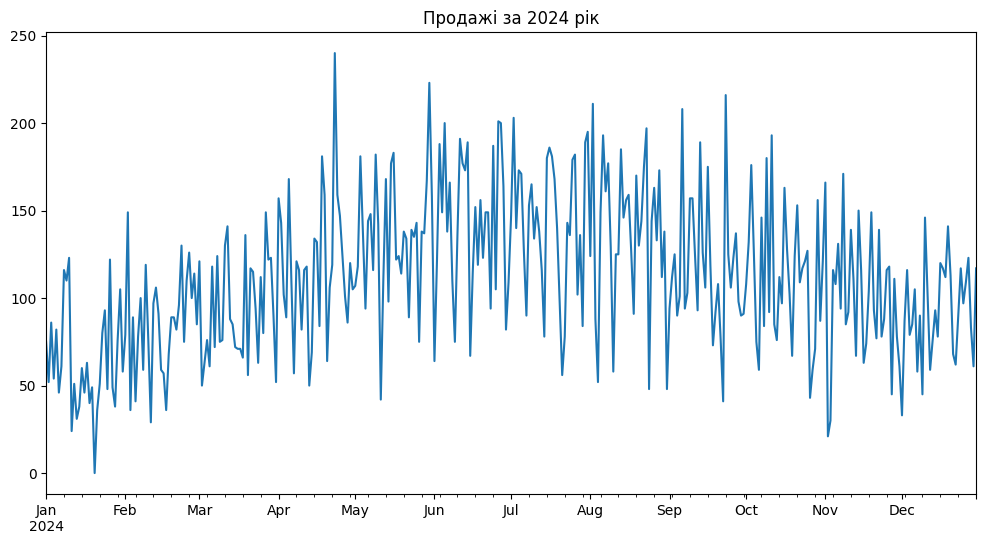

In [ ]:
# Найпростіший спосіб - метод plot()
sales_data['sales'].plot(
    figsize=(12, 6), title='Продажі за 2024 рік'
    )
plt.show()

Якщо ми хочемо зобразити кілька графіків на одному полотні (figure) - це легко зробити. Важливо, аби дані були на тому ж рівні деталізації.

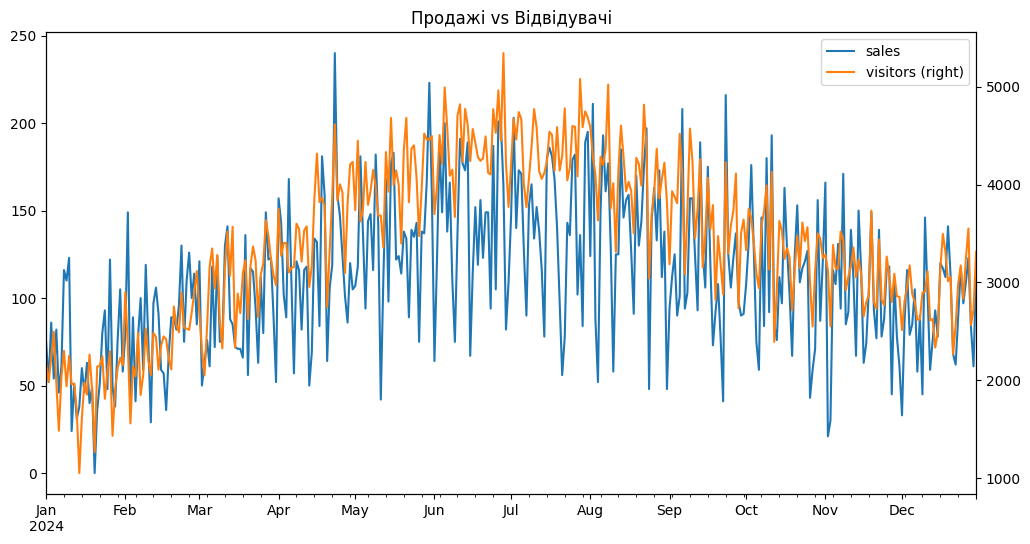

In [ ]:
# Кілька серій одразу
sales_data[['sales', 'visitors']].plot(
    figsize=(12, 6),
    secondary_y='visitors',
    title='Продажі vs Відвідувачі'
    );

Цей графік не є ефективним, адже на ньому не видно тенденцій. Далі розберемо, що робити в таких випадках.

### Доступні типи візуалізацій в Pandas

**Через метод `plot` в Pandas доступна побудова і інших типів візуалізацій:**
- `'line'` - лінійний графік (за замовчуванням)
- `'bar'` - вертикальна стовпчаста діаграма
- `'barh'` - горизонтальна стовпчаста діаграма
- `'hist'` - гістограма
- `'box'` - коробковий графік (boz and whiskers)
- `'kde'` або `'density'` - графік щільності
- `'area'` - площадний графік
- `'scatter'` - діаграма розсіювання
- `'hexbin'` - гексагональна діаграма
- `'pie'` - кругова діаграма

📚 **Офіційна документація**: [pandas.DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)

**Два способи побудови графіків з `plot()`:**

```python
# Спосіб 1: через параметр kind
df.plot(kind='bar', figsize=(10, 6))
df.plot(kind='scatter', x='col1', y='col2')

# Спосіб 2: через методи-аксесори (зручніше)
df.plot.bar(figsize=(10, 6))
df.plot.scatter(x='col1', y='col2')
```

💡 **Порада**: Використовуйте методи-аксесори (другий спосіб) - це зручніше для читання коду та автодоповнення в IDE.


## Різні типи графіків у Pandas

### Лінійний графік (Line Plot)
**Коли використовувати**: Часові ряди (коли маємо метрику, що вимірюється в рівні проміжки часу, наприклад, поденні продажі), тренди, зміни у часі.

Як ми вже побачили, простий лінійний графік нам дає на цих даних не ефективний результат, бо дані - по денні і сильно флуктуюють (змінюються в кожній наступній точці). Аби зробити візуалізацію більш інформативною - ми можемо загрегувати дані, наприклад, помісячно. Для цього використовуємо метод `resample`.

Більше про resampling і за якими періодами ми можемо агрегувати дані - тут https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#resampling

Побудуємо новий лінійний графік і подивимось, як ми його можемо налаштувати.

In [ ]:
# Місячні продажі

monthly_sales = sales_data['sales'].resample('ME').sum()

In [ ]:
monthly_sales

,sales
2024-01-31,1963
2024-02-29,2465
2024-03-31,2869
2024-04-30,3559
2024-05-31,4185
2024-06-30,4250
2024-07-31,4420
2024-08-31,4231
2024-09-30,3550
2024-10-31,3490


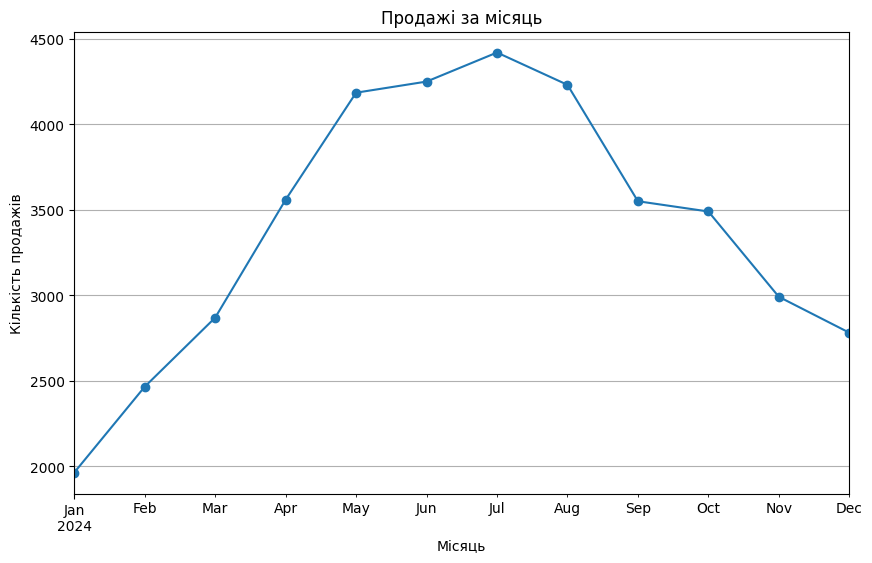

In [ ]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Продажі за місяць',
    xlabel='Місяць',
    ylabel='Кількість продажів',
    grid=True
);

Зараз видно чітку картину. До слова, ми б могли додати так само вторинну вісь з кількістю відвідувачів, що допоможе зробити глибший аналіз.

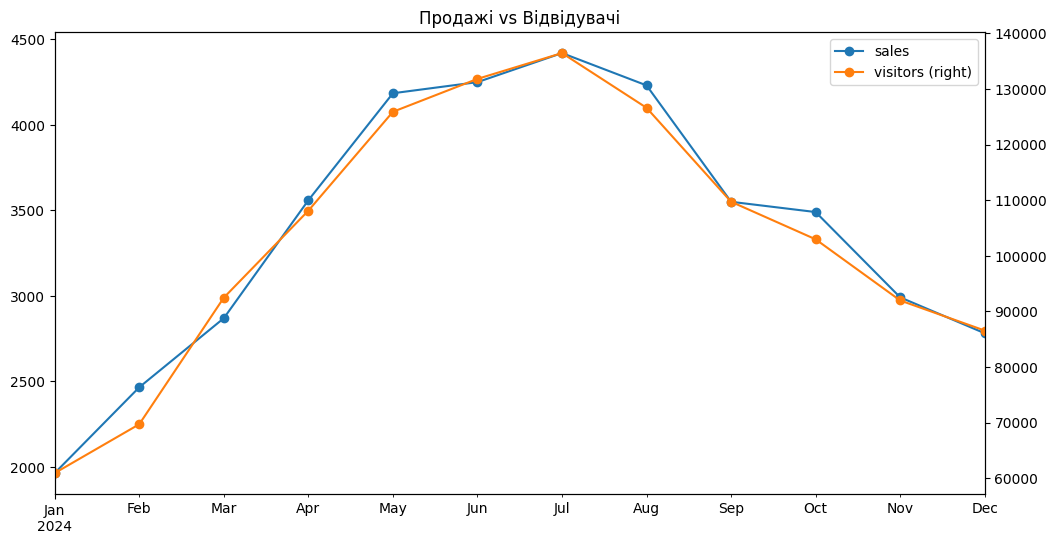

In [ ]:
# Кілька серій на одному полотні
monthly_data = sales_data[['sales', 'visitors']].resample('ME').sum()
monthly_data.plot(
    figsize=(12, 6),
    marker='o',
    secondary_y='visitors',
    title='Продажі vs Відвідувачі'
);

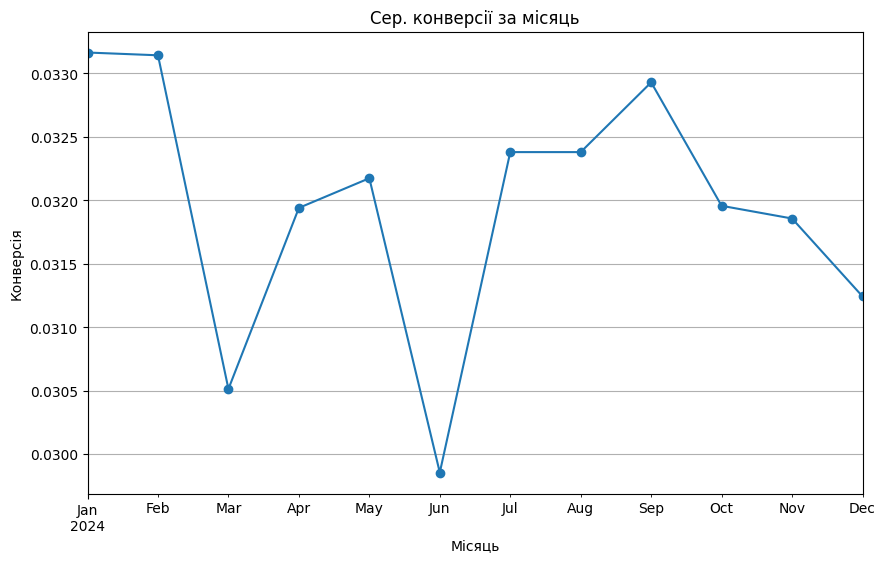

In [ ]:
sales_data['conversion'].resample('ME').mean().plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Сер. конверсії за місяць',
    xlabel='Місяць',
    ylabel='Конверсія',
    grid=True
);

Якщо б нам хотілось додати до аналізу ще часових рядів, ще і з зовсім іншими одиницями виміру - то вже це було б неефективно.
В такому випадку краще розбити графіки на підграфіки - `subplots`.

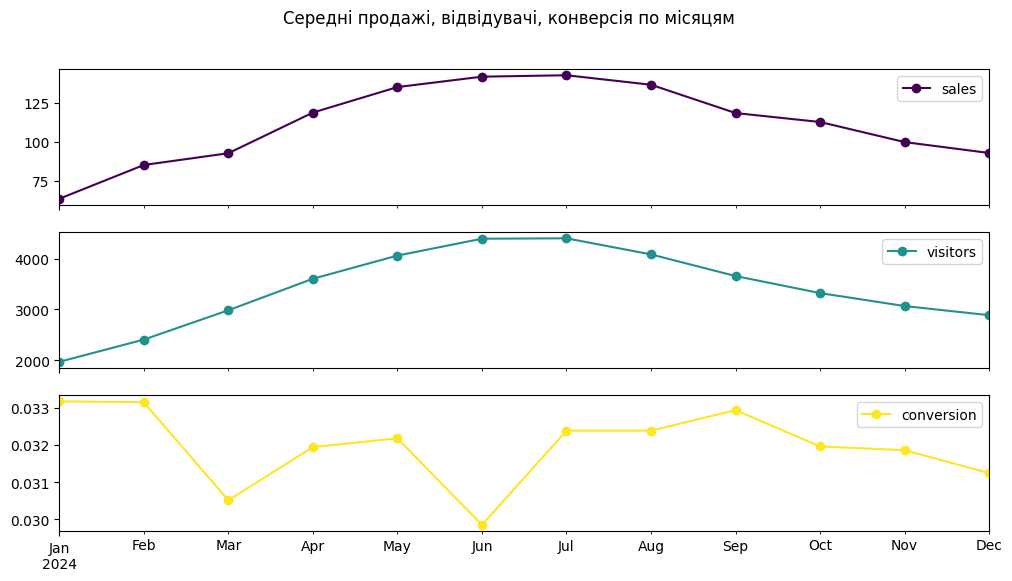

In [ ]:
# Кілька серій одразу
monthly_data = sales_data[['sales', 'visitors', 'conversion']].resample('ME').mean()
monthly_data.plot(
    figsize=(12, 6),
    marker='o',
    subplots=True,
    colormap='viridis',
    title='Середні продажі, відвідувачі, конверсія по місяцям'
);

Кольори і кольорові гами ми можемо зазначати словами, або спеціальними позначеннями. Детальніше [тут](https://matplotlib.org/stable/gallery/color/named_colors.html).


А що якщо ми хочемо визначити свої межі по осі ОУ? Для цього треба тонке налаштування, яке можливе з використанням безпосередньо бібліотеки `maplotlib`.


### Стовпчаста діаграма (Bar Plot)
**Коли використовувати**: Порівняння категорій, дискретні дані

В цих графіках покажу, як додавати налаштування з `maplotlib`, коли відповідника немає в `pandas.plot()`. Деякі налаштування можна задати як в методі `plot()`, так і в `maplotlib`.

In [ ]:
sales_data.nlargest(10, 'income')

,visitors,sales,conversion,avg_order_value,income
2024-06-05,4993,200,0.037717,157.307488,31461.497549
2024-08-02,4288,211,0.040719,146.983643,31013.548600
2024-07-15,4233,180,0.045377,172.248134,31004.664134
2024-07-02,4673,203,0.036856,151.308902,30715.707089
2024-05-30,4458,223,0.038777,135.775714,30277.984266
2024-06-24,4771,187,0.039178,160.850616,30079.065198
2024-06-11,4820,191,0.035240,153.810673,29377.838613
2024-06-14,4613,189,0.038193,155.409806,29372.453397
2024-08-23,4351,197,0.038785,148.984709,29349.987698
2024-06-27,4447,200,0.042208,146.633621,29326.724196


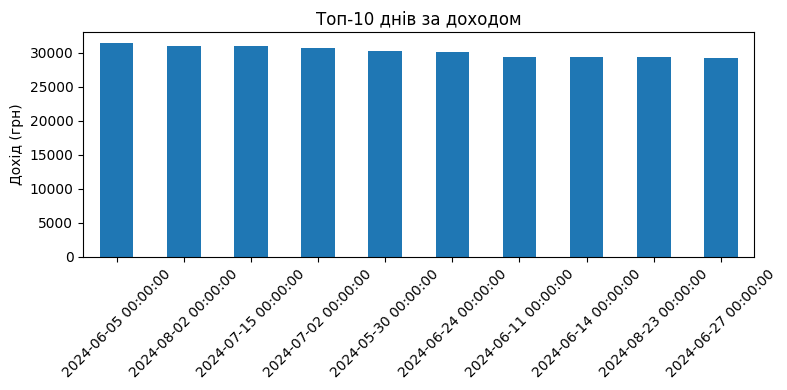

In [ ]:
# Топ-10 днів за доходом
top_days = sales_data.nlargest(10, 'income')['income']
top_days.plot.bar(
    figsize=(8, 4),
    # color='skyblue',
    title='Топ-10 днів за доходом',
    ylabel='Дохід (грн)',
)
plt.xticks(rotation=45)
plt.tight_layout()


Тут у нас вивівся час, але нам він не треба. Ми можемо це налаштувати.

In [ ]:
top_days.index

DatetimeIndex(['2024-06-05', '2024-08-02', '2024-07-15', '2024-07-02',
               '2024-05-30', '2024-06-24', '2024-06-11', '2024-06-14',
               '2024-08-23', '2024-06-27'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
[date.strftime('%d %b %Y') for date in top_days.index]

['05 Jun 2024',
 '02 Aug 2024',
 '15 Jul 2024',
 '02 Jul 2024',
 '30 May 2024',
 '24 Jun 2024',
 '11 Jun 2024',
 '14 Jun 2024',
 '23 Aug 2024',
 '27 Jun 2024']

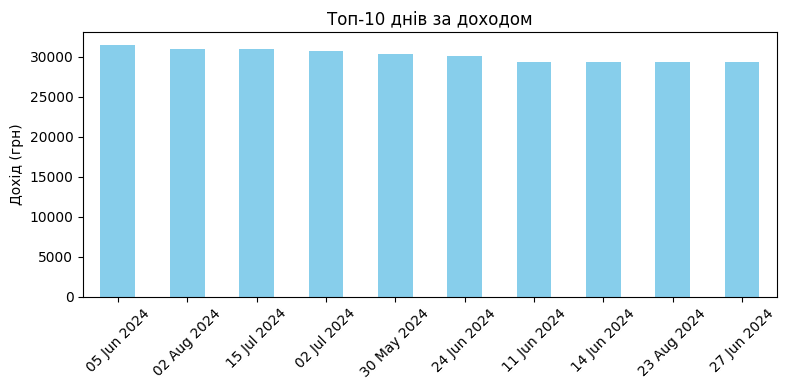

In [ ]:
# Форматуємо дати для кращого відображення
ax = top_days.plot.bar(
    figsize=(8, 4),
    color='skyblue',
    title='Топ-10 днів за доходом',
    ylabel='Дохід (грн)'
)

# Форматуємо підписи осі X - тільки дата та скорочена назва місяця
labels = [date.strftime('%d %b %Y') for date in top_days.index]
ax.set_xticklabels(labels)
plt.xticks(rotation=45)
plt.tight_layout()

Які є доступні способи форматування дати - можна знайти тут в документації: https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior

Давайте розглянемо приклад вертикального стовпачтого графіку.

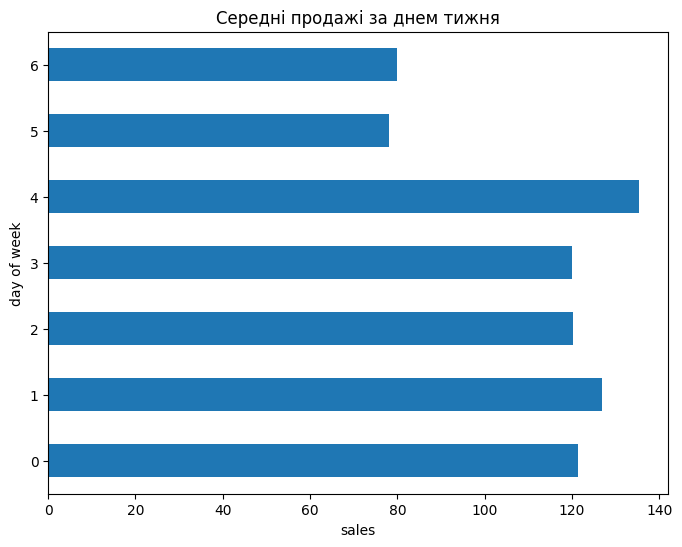

In [ ]:
# Горизонтальна версія
sales_data.groupby(sales_data.index.weekday)['sales'].mean().plot.barh(
    figsize=(8, 6),
    title='Середні продажі за днем тижня',
    xlabel='sales',
    ylabel='day of week',
);

Все клас, тільки хочеться не номер дня тижня, а назву.

In [ ]:
avg_sales_by_day = sales_data.groupby(sales_data.index.weekday)['sales'].mean()

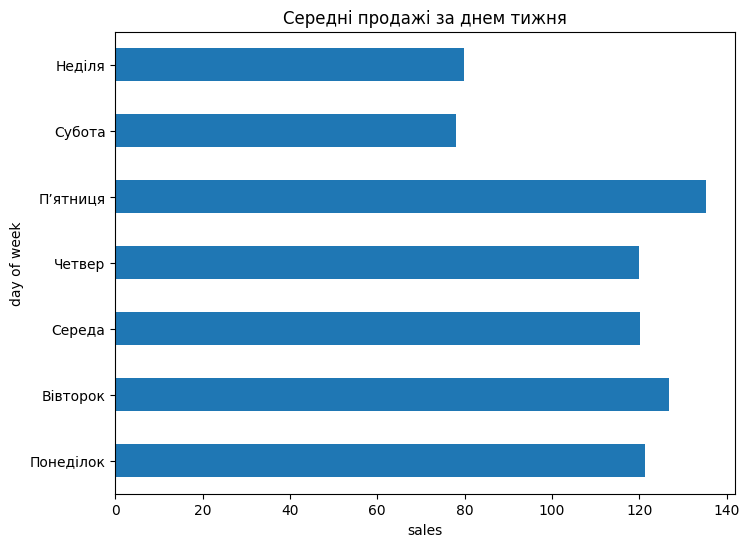

In [ ]:
ax = avg_sales_by_day.plot.barh(
    figsize=(8, 6),
    title='Середні продажі за днем тижня',
    xlabel='sales',
    ylabel='day of week',
    )


# Налаштування підписів
ax.set_yticklabels(['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'Пʼятниця', 'Субота', 'Неділя']);


**Важливо зрозуміти:**

з Python ви можете відредагувати візуалізацію як завгодно на свій смак 👌
Найглибше, куди ви можете піти - це в matplotlib. Якщо маєте специфічні побажання до візуалізації - часто найшвидше і найпростіше попросити ChatGPT або Claude зібрати код для вас. Але для правок ви маєте розуміти, що відбувається "під капотом".

### Гістограма (Histogram)
**Коли використовувати**: Розподіл даних, частота значень

Побудуємо гістограму конверсій і покажу, як додати на неї лінію, наприклад, аби позначити середнє значення.

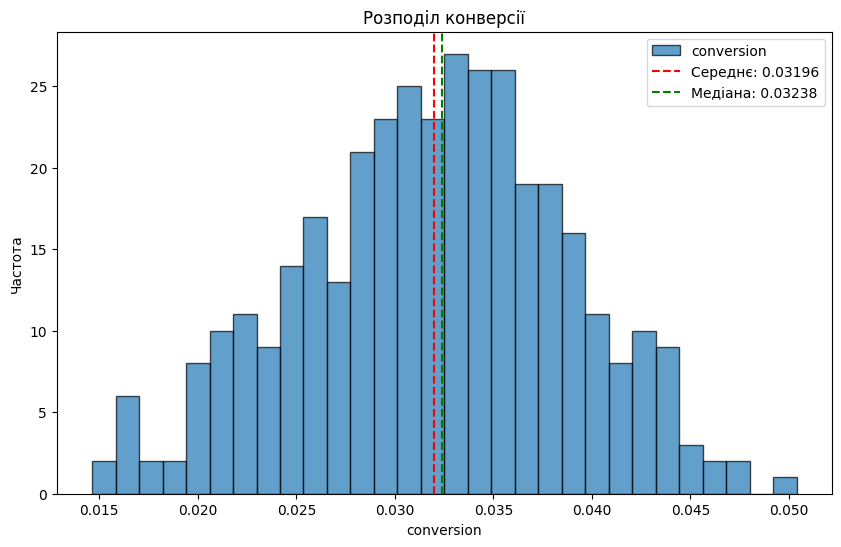

In [ ]:
# Розподіл конверсії
sales_data['conversion'].plot.hist(
    bins=30,
    figsize=(10, 6),
    alpha=0.7,
    edgecolor='black',
    title='Розподіл конверсії',
    xlabel='conversion',
    ylabel='Частота',
)
plt.axvline(
    sales_data['conversion'].mean(),
    color='red',
    linestyle='--',
    label=f"Середнє: {sales_data['conversion'].mean():.5f}"
)
plt.axvline(
    sales_data['conversion'].median(),
    color='green',
    linestyle='--',
    label=f"Медіана: {sales_data['conversion'].median():.5f}"
)
plt.legend();


### Коробковий графік (Box Plot)
**Коли використовувати**: Статистичний розподіл, виявлення викидів

Існує два способи побудови Box Plot в Pandas.

**`df.plot.box()` vs `df.boxplot()`**

Обидва методи можуть будувати box plots з групуванням через параметр `by`. Основні відмінності:

**`df.plot.box()`**
- Частина загального plot API (консистентність з `.plot.line()`, `.plot.bar()` тощо)
- Повертає axes об'єкт
- Синтаксис: `df.plot.box(by='category')`

**`df.boxplot()`**
- Спеціалізований метод саме для box plots
- Автоматично додає заголовок з групуванням (потрібно видаляти через `plt.suptitle('')`)
- Має додаткові параметри для тонкого налаштування
- Синтаксис: `df.boxplot(column='value', by='category')`

На практиці:
- Використовуйте **`plot.box()`** для консистентності з іншими типами графіків
- Використовуйте **`boxplot()`** якщо потрібні специфічні налаштування box plot

Функціонально вони майже ідентичні, різниця більше в стилі коду та деяких деталях відображення.

In [ ]:
# Розподіл продажів за днями тижня
sales_data['weekday'] = sales_data.index.day_name()

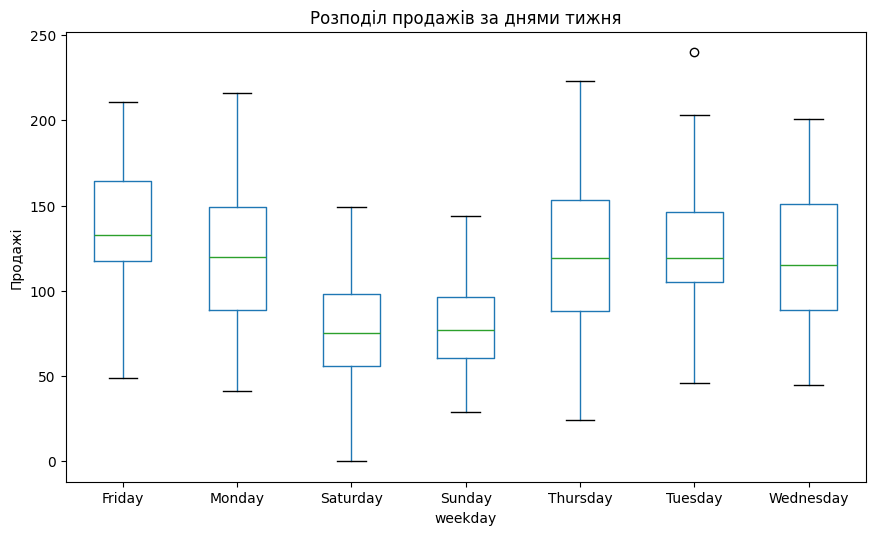

In [ ]:
# Спосіб 1: через boxplot() - зручніше для групування
sales_data.boxplot(
    column='sales',
    by='weekday',
    figsize=(10, 6),
    grid = False
)
plt.title('Розподіл продажів за днями тижня')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.ylabel('Продажі')
plt.show()

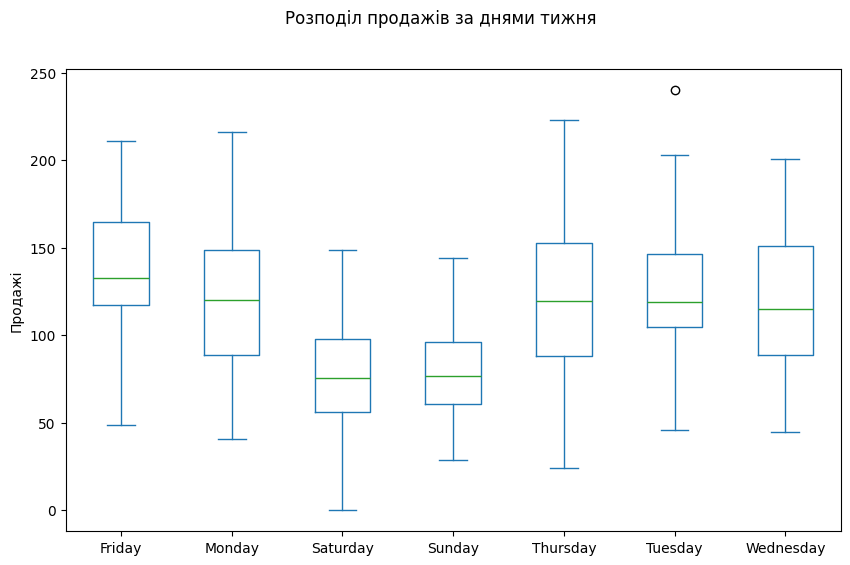

In [ ]:
# Спосіб 2: через plot.box()
sales_data[['sales', 'weekday']].plot.box(
    by='weekday',
    figsize=(10, 6),
    title='Розподіл продажів за днями тижня',
    ylabel='Продажі'
)
plt.title('');

Все добре, крім того, що у нас **неправильний порядок днів тижня**. Аби його виправити - треба виконати додаткову підготовку даних.

In [ ]:
# 1. Встановлюємо правильний порядок днів
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Задаємо категорійну змінну з порядком для weekday
sales_data['weekday'] = pd.Categorical(sales_data['weekday'], categories=ordered_days, ordered=True)

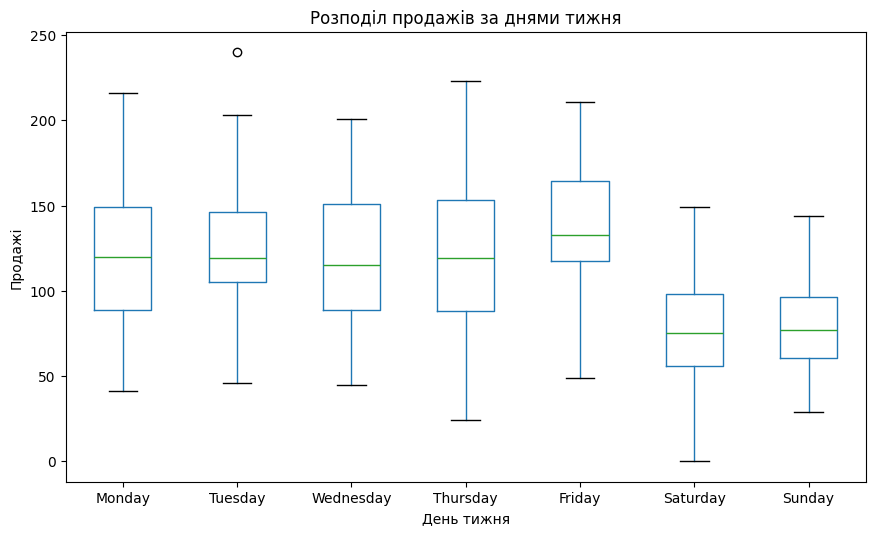

In [ ]:
# 3. Побудова boxplot з англійськими днями
sales_data.boxplot(
    column='sales',
    by='weekday',
    figsize=(10, 6),
    grid=False
)
plt.title('Розподіл продажів за днями тижня')
plt.ylabel('Продажі')
plt.xlabel('День тижня')
plt.suptitle('')  # Прибирає автоматичний заголовок
plt.show()



### Діаграма розсіювання (Scatter Plot)
**Коли використовувати**: Кореляції, залежності між змінними


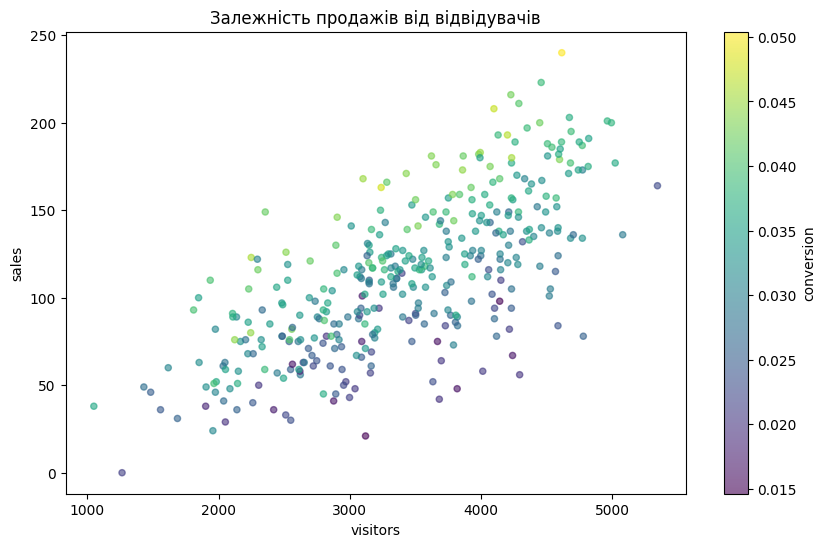

In [ ]:
# Залежність продажів від відвідувачів
sales_data.plot.scatter(
    x='visitors',
    y='sales',
    c='conversion',
    colormap='viridis',
    title='Залежність продажів від відвідувачів',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()


### Кругова діаграма (Pie Chart)
**Коли використовувати**: Частки від цілого (з обережністю!)


In [ ]:
# Частка продажів за кварталами
quarterly_sales = sales_data['sales'].resample('QE').sum()

In [ ]:
quarterly_sales

,sales
2024-03-31,7297
2024-06-30,11994
2024-09-30,12201
2024-12-31,9262


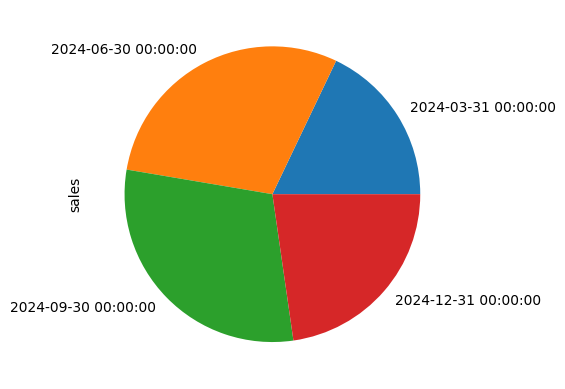

In [ ]:
quarterly_sales.plot.pie(
    # # figsize=(8, 8),
    # autopct='%1.1f%%',
    # labels=['Q1', 'Q2', 'Q3', 'Q4'],
    # title='Частка продажів за кварталами',
    # ylabel='',
);

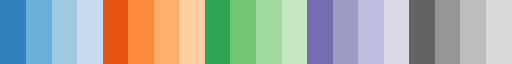

In [ ]:
plt.cm.tab20c

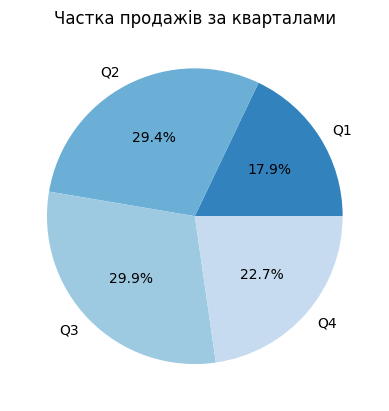

In [ ]:
quarterly_sales.plot.pie(
    # figsize=(8, 8),
    autopct='%1.1f%%',
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    title='Частка продажів за кварталами',
    ylabel='',
    colors=plt.cm.tab20c.colors
);


### Area Plot
**Коли використовувати**: Накопичувальні дані, внесок компонентів в динаміці


In [ ]:
# Створимо дані про канали продажів
channels = pd.DataFrame({
    'Онлайн': sales_data['sales'] * 0.6,
    'Офлайн': sales_data['sales'] * 0.3,
    'Партнери': sales_data['sales'] * 0.1
}, index=sales_data.index)

In [ ]:
import numpy as np

In [ ]:
np.allclose(channels.sum(axis=1), sales_data['sales'])

True

In [ ]:
channels[:5]

,Онлайн,Офлайн,Партнери
2024-01-01,45.0,22.5,7.5
2024-01-02,31.2,15.6,5.2
2024-01-03,51.6,25.8,8.6
2024-01-04,32.4,16.2,5.4
2024-01-05,49.2,24.6,8.2


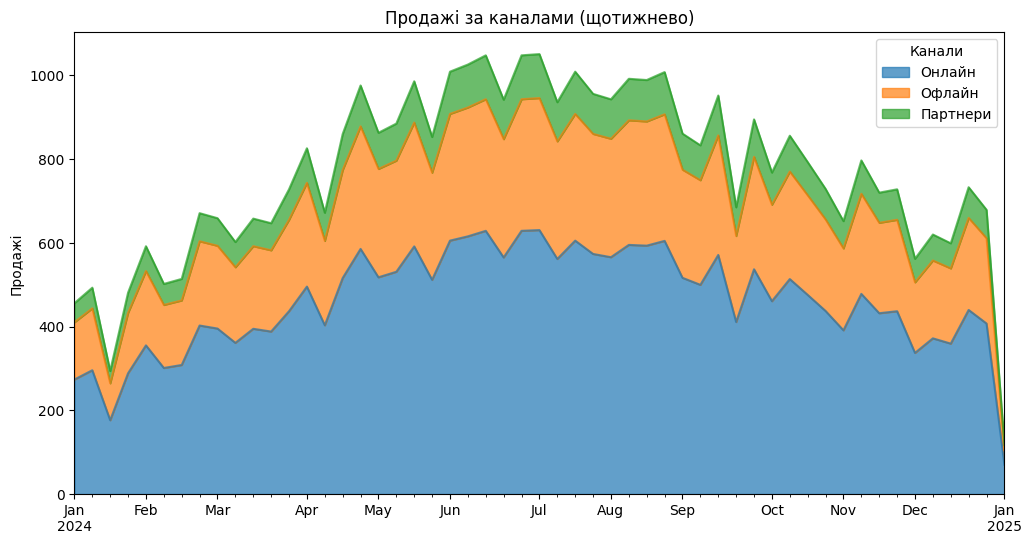

In [ ]:
channels.resample('W').sum().plot.area(figsize=(12, 6), alpha=0.7)
plt.title('Продажі за каналами (щотижнево)')
plt.ylabel('Продажі')
plt.legend(title='Канали')
plt.show()

### 📤 Експорт графіка у файл

Можемо зберегти графік у файл двома способами:

🔹 **У Jupyter Notebook:**

* наведіть курсор на графік;
* натисніть праву кнопку миші → *Save Image As...*;
* виберіть формат і збережіть.

🔹 **Програмно через `plt.savefig()`**

Викликаємо `plt.savefig()` після побудови графіку і до plt.show().

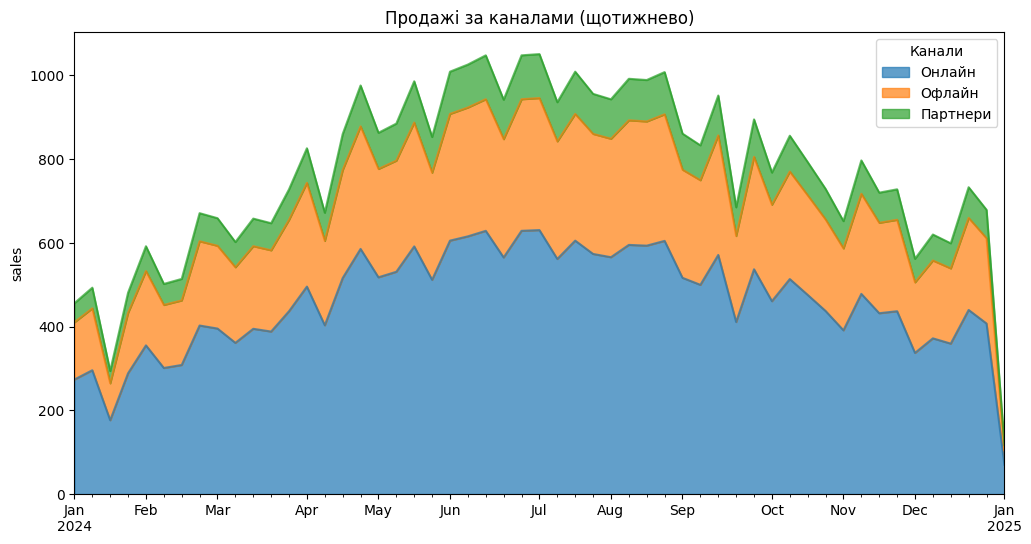

In [ ]:
channels.resample('W').sum().plot(kind='area', figsize=(12, 6), alpha=0.7)
plt.title('Продажі за каналами (щотижнево)')
plt.ylabel('sales')
plt.legend(title='Канали')
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()


📌 Параметри:

* `'my_plot.png'` — шлях до файлу (можна `.jpg`, `.svg`, `.pdf` тощо);
* `dpi=300` — роздільна здатність (для друку бажано ≥300);
* `bbox_inches='tight'` — обрізає зайві поля довкола графіка.

> ⚠️ **Важливо:** виклик `plt.savefig()` **має бути до `plt.show()`**, бо після `show()` фігура очищається, і збережеться порожній файл.

Ось коротке та чітке пояснення, **в чому різниця між форматами `png`, `jpeg`, `svg`** під час експорту графіків у Python:

---

### 🖼️ Основні формати при збереженні графіків

Ми можемо зберегти статичний графік у **растровому** або **векторному** форматі.

* **Растровий (PNG, JPEG)** — складається з пікселів. Добре для перегляду, але **втрачає якість при масштабуванні (приближенні)**.
* **Векторний (SVG, PDF)** — будується з ліній і формул. **Масштабується без втрати якості**, зручно для друку і редагування.

📌 Растр = фото
📌 Вектор = формула


| Формат | Тип       | Коли використовувати                                        | Особливості                                                                    |
| ------ | --------- | ----------------------------------------------------------- | ------------------------------------------------------------------------------ |
| `PNG`  | растровий | 🔸 Для презентацій, ноутбуків, web-сторінок                 | ✔ прозорий фон<br>✔ чіткість<br>❌ більший розмір                               |
| `JPEG` | растровий | 🔸 Для звітів у Word або PDF                                | ✔ менший розмір<br>❌ гірша якість<br>❌ немає прозорості                        |
| `SVG`  | векторний | 🔸 Для друку, редагування в Adobe Illustrator, Figma, Canva | ✔ масштабування без втрати якості<br>✔ зручно для дизайну<br>❌ складніший файл |

---

### 🧠 Що обрати?

* **`PNG`** — найуніверсальніший варіант. Висока якість, прозорість, добре виглядає в презентаціях та Jupyter Notebook.
* **`JPEG`** — якщо важливий малий розмір файлу, але не критична якість (рідко використовують для графіків).
* **`SVG`** — ідеально для **векторної графіки**: логотипи, публікації, дизайнерські макети.


## 5. Бібліотека Matplotlib

Matplotlib — базова бібліотека для візуалізації даних у Python. Дає повний контроль над побудовою графіків, хоча може вимагати більше коду для налаштувань.

**Використовуйте Matplotlib коли:**
- Потрібна тонка настройка кожного елемента
- Створюєте складні композиції з кількох графіків

Найчастіше, коли працюєте з Pandas, ви будете використовувати Matplotlib, коли вам не вистачає фукнціоналу Pandas, або аби дописати якісь деталі, або аби повністю створити певний тип візуалізації.

Графіки в matplotlib будуються подібно до pandas, але трошки більше коду.

Давайте порівняємо.

In [ ]:
monthly_sales = sales_data['sales'].resample('ME').sum()
monthly_sales.head()

,sales
2024-01-31,1963
2024-02-29,2465
2024-03-31,2869
2024-04-30,3559
2024-05-31,4185


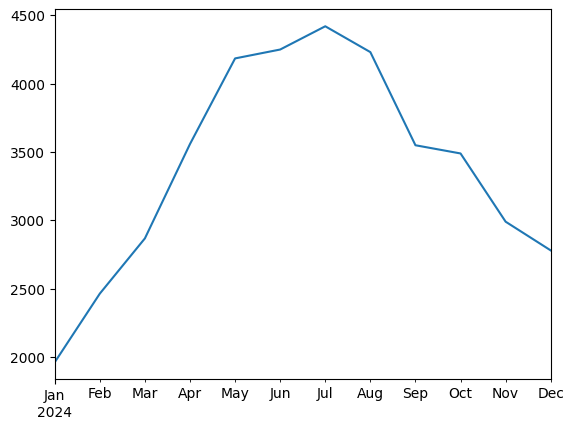

In [ ]:
# viz with Pandas
monthly_sales.plot();

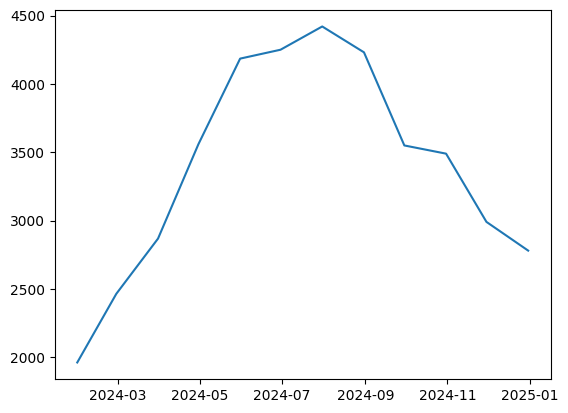

In [ ]:
# viz with Matplotlib
plt.plot(monthly_sales);

In [ ]:
plt.plot(monthly_sales.index, monthly_sales.values)
# plt.xticks(rotation=45)
plt.title('Місячні продажі')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.tight_layout()
plt.show()

### Приципова різниця в побудові графіків з Pandas vs Matplotlib

В Pandas ми викликаємо метод `.plot()` напряму з об'єкта Series або DataFrame. Більшість параметрів передаються одразу в метод — це швидкий спосіб побудови базового графіка. І як ми вже розглянули, базовий графік надалі може бути доповнений деталями з Matplotlib.

Документація методу `plt.plot`: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

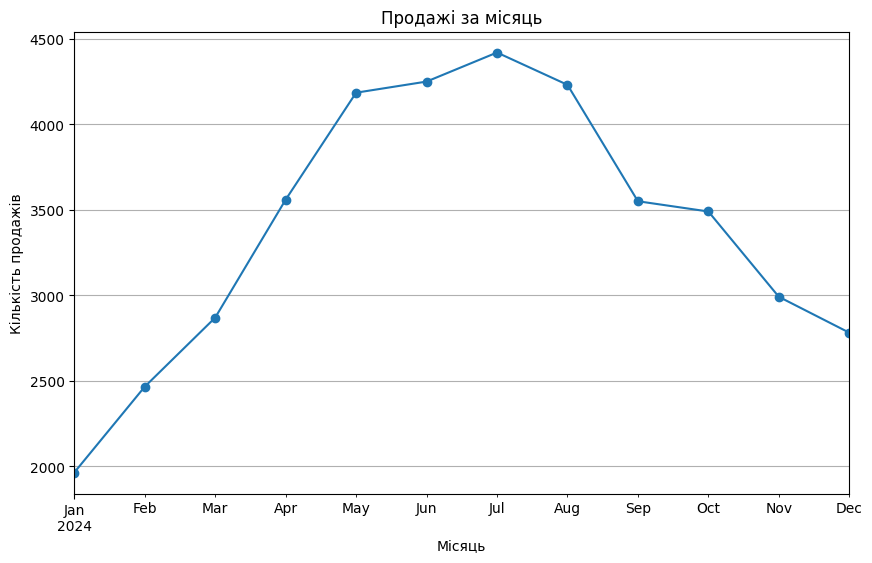

In [ ]:
# detailed viz with Pandas
monthly_sales.plot(
    marker='o',
    figsize=(10, 6),
    title='Продажі за місяць',
    xlabel='Місяць',
    ylabel='Кількість продажів',
    grid=True
);

У Matplotlib підхід низькорівневий — ви самостійно викликаєте `plt.figure()`, окремо додаєте кожен елемент (заголовок, підписи, сітку). Це дає більше контролю, але потребує більше кроків і щоразу писати `plt.`.



In [ ]:
?plt.figure

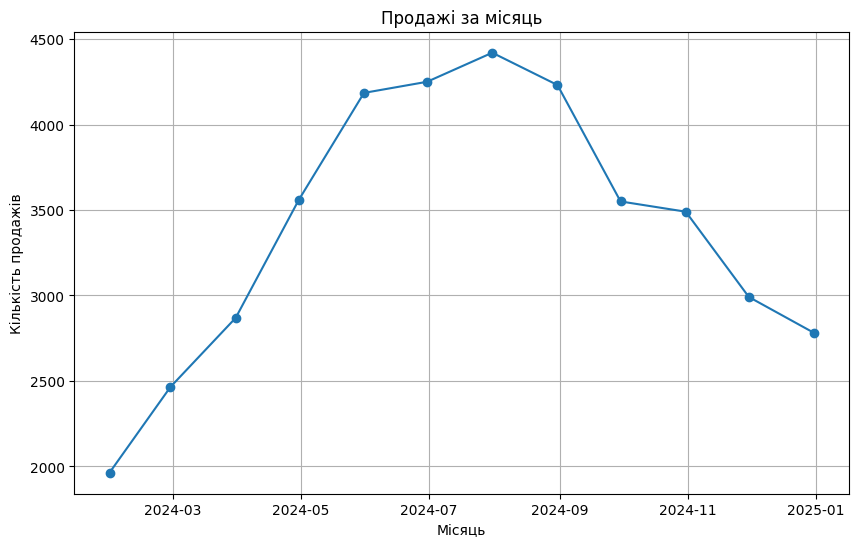

In [ ]:
# detailed viz with matplotlib
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales, 'o-')
plt.title('Продажі за місяць')
plt.xlabel('Місяць')
plt.ylabel('Кількість продажів')
plt.grid(True);

### Побудова двох графіків на одному полотні
До цього ми працювали з датафреймом, в якому є лише 1 колонка. А що, якщо нам треба відобразити декілька?
Створимо новий датафрейм.

In [ ]:
monthly_stats = sales_data['sales'].resample('ME').agg(['mean', 'max', 'min'])
monthly_stats

,mean,max,min
2024-01-31,63.322581,123,0
2024-02-29,85.000000,149,29
2024-03-31,92.548387,149,50
2024-04-30,118.633333,240,50
2024-05-31,135.000000,223,42
2024-06-30,141.666667,201,64
2024-07-31,142.580645,203,56
2024-08-31,136.483871,211,48
2024-09-30,118.333333,216,41
2024-10-31,112.580645,193,43


Графік з Pandas.

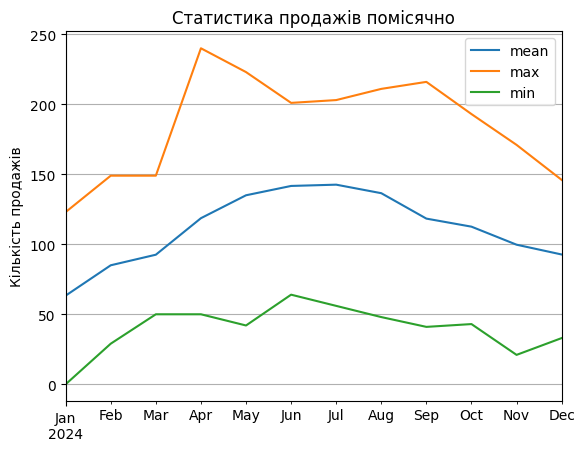

In [ ]:
monthly_stats.plot(
    title='Статистика продажів помісячно',
    ylabel='Кількість продажів',
    grid=True);

**Що змінюється при з Matplotlib?**

1. **Ви явно викликаєте `plt.plot()` для кожної серії окремо.**

  У Pandas це все робиться автоматично — якщо в DataFrame кілька колонок, то всі вони виводяться одним `.plot()`.

2. **Осьову шкалу по X треба не вказувати, бо Matplotlib автоматично використовує індекс DataFrame**, так само як і Pandas — у цьому випадку змін не буде, якщо `monthly_stats.index` — це `DatetimeIndex`.

3. **Додавання легенди та сітки потрібно робити вручну:**
   У Pandas `.plot()` за замовчуванням уже додає легенду і стилі. У Matplotlib ви самі додаєте `plt.legend()`, `plt.grid()` тощо.

4. **Кольори для кожної нової лінії на призначаються автоматично, як і в Pandas**.
   Але також можемо задати певний колір кожній лінії.

Обидва варіанти (Pandas і matplotlib) — правильні. Обирайте залежно від цілі: **швидко подивитись** чи **тонко налаштувати**.


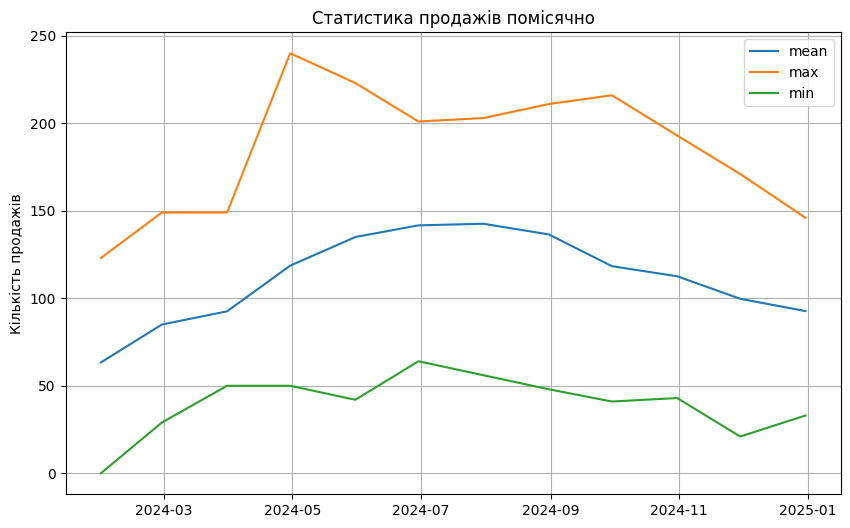

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_stats['mean'], label='mean')
plt.plot(monthly_stats['max'], label='max')
plt.plot(monthly_stats['min'], label='min')

plt.title('Статистика продажів помісячно')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()


### Matplotlib для візуалізацій НЕ DataFrame

Matplotlib вміє працювати не лише з DataFrame, а і списки та numpy.arrays. Працює все так само: маємо передати структуру, яка задає позначки за віссю x і за віссю y.

Якщо не задаємо х, то в лінійному графіку вони будуть згенеровані автоматично. В більшості інших типів графіків (bar, box) маємо обовʼязково задавати х.

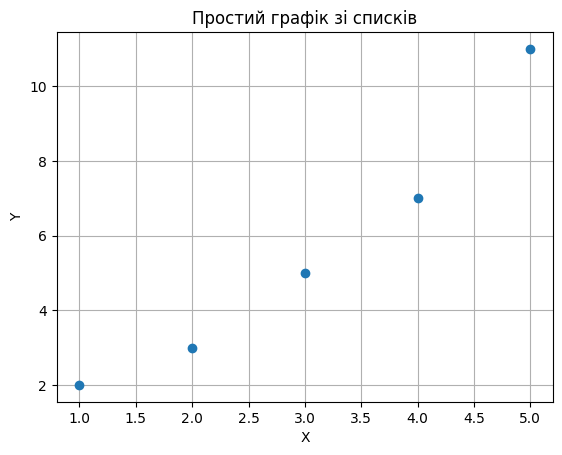

In [ ]:
# Дані у вигляді списків
x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 7, 11]

# Побудова графіка
plt.plot(x, y, 'o')
# plt.bar(x, y)

# Оформлення
plt.title('Простий графік зі списків')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

Графік для numpy масивів.

In [ ]:
import numpy as np

x = np.linspace(10, 20, 100)

In [ ]:
x

array([10.        , 10.1010101 , 10.2020202 , 10.3030303 , 10.4040404 ,
       10.50505051, 10.60606061, 10.70707071, 10.80808081, 10.90909091,
       11.01010101, 11.11111111, 11.21212121, 11.31313131, 11.41414141,
       11.51515152, 11.61616162, 11.71717172, 11.81818182, 11.91919192,
       12.02020202, 12.12121212, 12.22222222, 12.32323232, 12.42424242,
       12.52525253, 12.62626263, 12.72727273, 12.82828283, 12.92929293,
       13.03030303, 13.13131313, 13.23232323, 13.33333333, 13.43434343,
       13.53535354, 13.63636364, 13.73737374, 13.83838384, 13.93939394,
       14.04040404, 14.14141414, 14.24242424, 14.34343434, 14.44444444,
       14.54545455, 14.64646465, 14.74747475, 14.84848485, 14.94949495,
       15.05050505, 15.15151515, 15.25252525, 15.35353535, 15.45454545,
       15.55555556, 15.65656566, 15.75757576, 15.85858586, 15.95959596,
       16.06060606, 16.16161616, 16.26262626, 16.36363636, 16.46464646,
       16.56565657, 16.66666667, 16.76767677, 16.86868687, 16.96

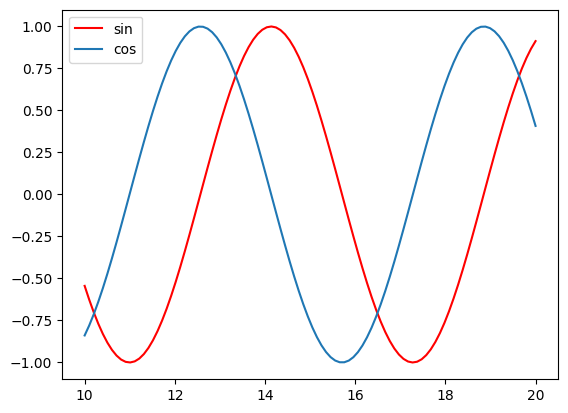

In [ ]:
plt.plot(x, np.sin(x), label='sin', color='red')
plt.plot(x, np.cos(x), label='cos')
plt.legend();

### Декілька графіків на одній фігурі в Matplotlib

Якщо є потреба побудувати 2 і більше окремих графіки на одній фігурі — для цього існує 2 основні підходи:

#### 🔹 Підхід 1 — `plt.subplot()`

Вважається підходом в стилі `matlab`, бо в тій системі графіки будуються саме так і багато дослідників свого часу переходили з `matlab` на `python`. Тож, цей стиль створили для простішого переходу.

**Простіший**, менш гнучкий, але швидкий для базових цілей.



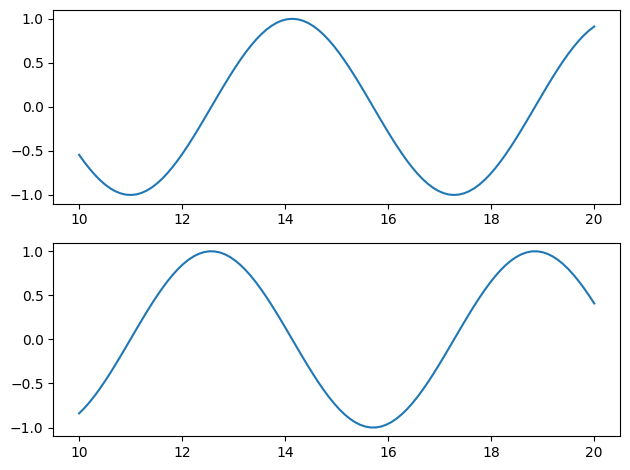

In [ ]:
plt.figure()  # створюємо фігуру

# створюємо першу з двох панелей і встановлюємо поточну вісь
plt.subplot(2, 1, 1)  # (рядки, колонки, номер панелі)
plt.plot(x, np.sin(x))

# створюємо другу з двох панелей і встановлюємо поточну вісь
plt.subplot(2, 1, 2)
plt.plot(x, np.cos(x));
plt.tight_layout();


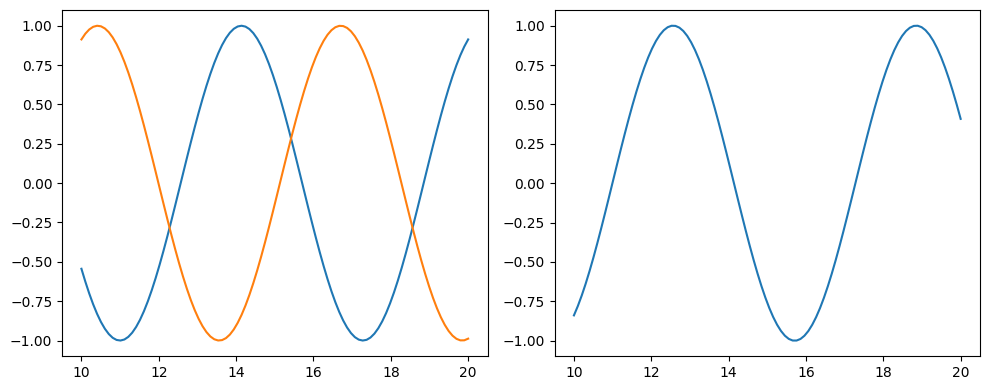

In [ ]:
plt.figure(figsize=(10,4))  # створюємо фігуру

# створюємо першу з двох панелей і встановлюємо поточну вісь
plt.subplot(1, 2, 1)  # (рядки, колонки, номер панелі)
plt.plot(x, np.sin(x))
plt.plot(x, np.sin(x+10))

# створюємо другу з двох панелей і встановлюємо поточну вісь
plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x));
plt.tight_layout();


📌 Ключові особливості:

* Ви явно вказуєте кількість рядків і колонок, а також номер панелі (як от `plt.subplot(2, 1, 1)`).
* Кожен `subplot()` автоматично встановлює поточну "вісь", з якою ми працюємо, і всі подальші в коді налаштування стосуватимуться саме цієї вісі.
* Всі графіки створюються через `plt.plot()` на активній панелі.
* Обмежений контроль над відступами, розміщенням, підписами і мітками осей.


#### 🔹 Підхід 2 — `fig, ax = plt.subplots(...)`

Він називається "обʼєктно-орієнтований".
**Більш гнучкий**, сучасний підхід. Дає більше контролю над кожним графіком.


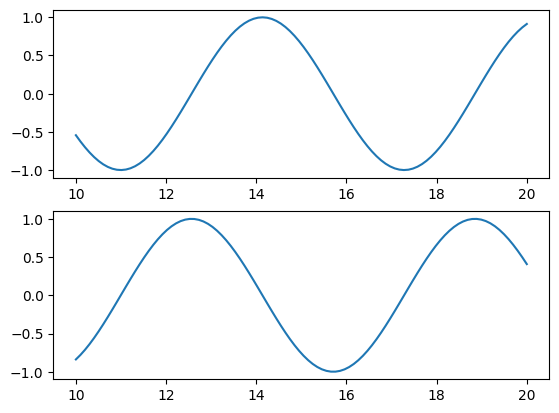

In [ ]:
fig, ax = plt.subplots(2)  # 2 рядки, 1 колонка (ax — масив вісей)
ax[0].plot(x, np.sin(x))
ax[1].plot(x, np.cos(x));

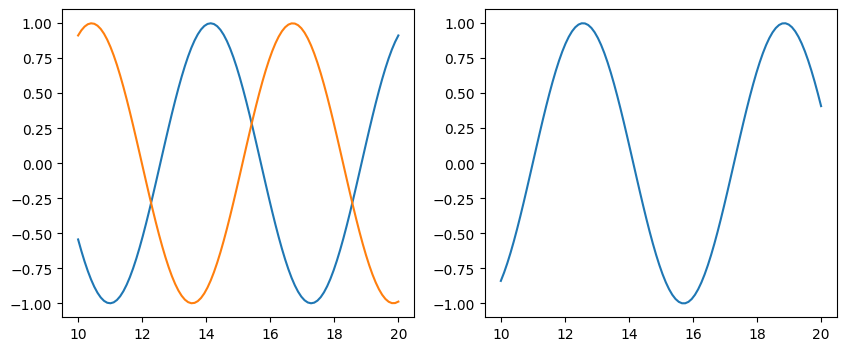

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))  # 2 рядки, 1 колонка (ax — масив вісей)
ax[0].plot(x, np.sin(x))
ax[1].plot(x, np.cos(x))
ax[0].plot(x, np.sin(x+10));

📌 Ключові особливості:

* `ax` — це масив `Axes`-об’єктів, до кожного з яких можна звертатися напряму.
* Дає повний контроль над кожним окремим графіком (осьові підписи, стилі, сітка тощо).
* Простіше масштабувати, наприклад: `fig, ax = plt.subplots(2, 3)` створює сітку 2×3.

**Розглянемо ще один, складніший приклад.**

Спочатку побудуємо з `plt.subplot()`.

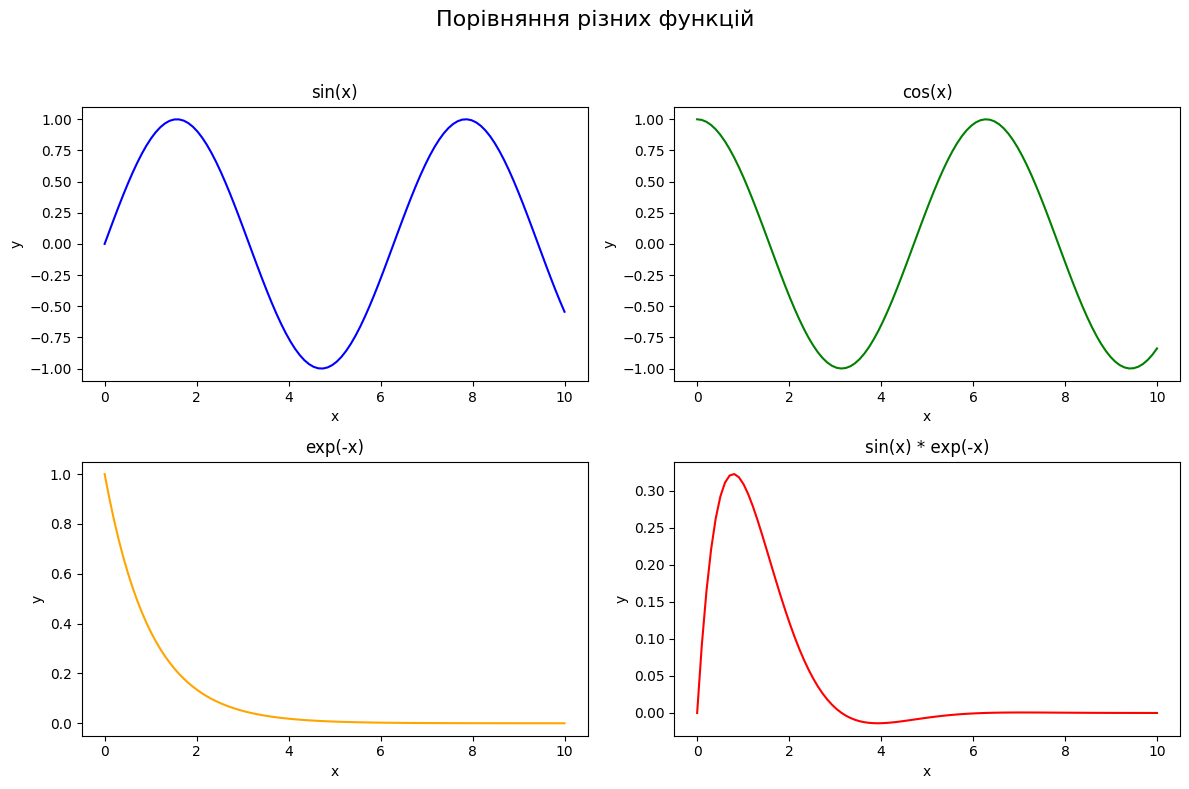

In [ ]:
# Дані
x = np.linspace(0, 10, 100)

plt.figure(figsize=(12, 8))

# Графік 1
plt.subplot(2, 2, 1)
plt.plot(x, np.sin(x), color='blue')
plt.title('sin(x)')
plt.xlabel('x')
plt.ylabel('y')

# Графік 2
plt.subplot(2, 2, 2)
plt.plot(x, np.cos(x), color='green')
plt.title('cos(x)')
plt.xlabel('x')
plt.ylabel('y')

# Графік 3
plt.subplot(2, 2, 3)
plt.plot(x, np.exp(-x), color='orange')
plt.title('exp(-x)')
plt.xlabel('x')
plt.ylabel('y')

# Графік 4
plt.subplot(2, 2, 4)
plt.plot(x, np.sin(x) * np.exp(-x), color='red')
plt.title('sin(x) * exp(-x)')
plt.xlabel('x')
plt.ylabel('y')

# Заголовок всієї фігури — треба обійтись без `fig.suptitle()`
plt.suptitle('Порівняння різних функцій', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Тепер побудуємо з `plt.subplots()`.

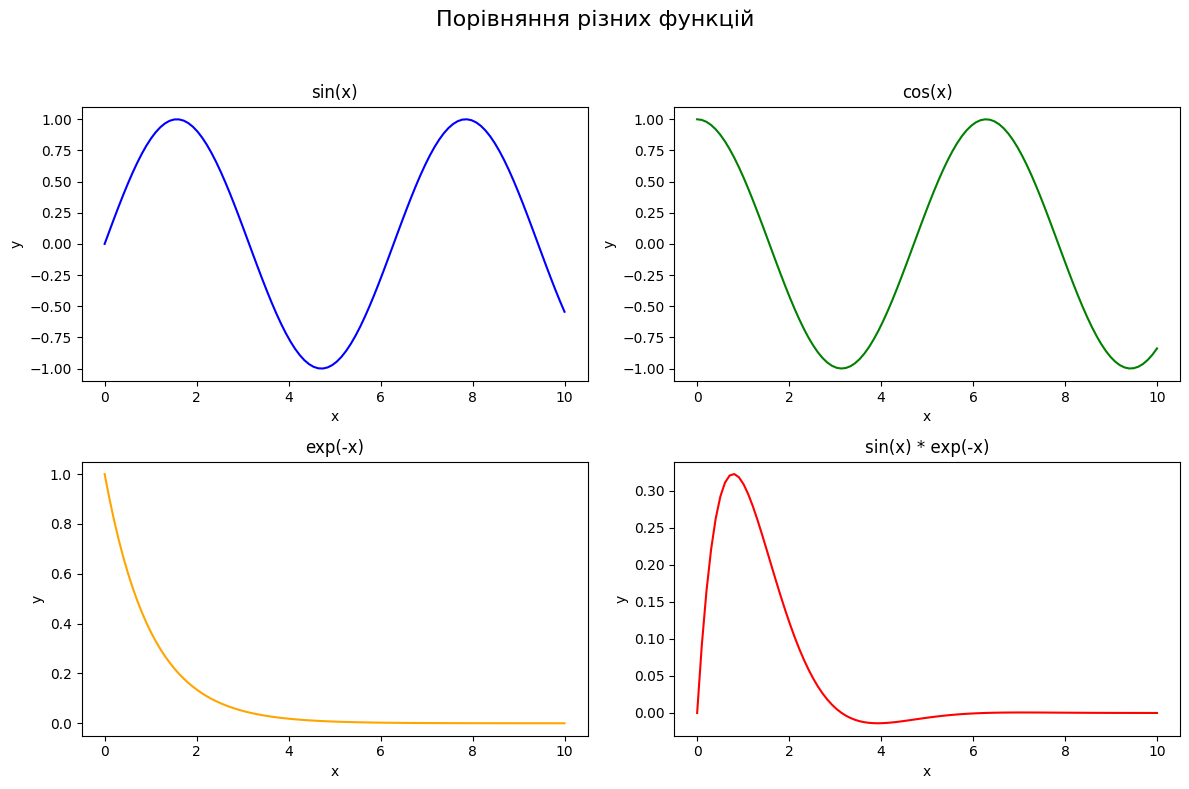

In [ ]:
# Дані
x = np.linspace(0, 10, 100)

# Створюємо 2x2 сітку графіків
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Верхній лівий — sin(x)
ax[0, 0].plot(x, np.sin(x), color='blue')
ax[0, 0].set_title('sin(x)')
ax[0, 0].set_xlabel('x')
ax[0, 0].set_ylabel('y')

# Верхній правий — cos(x)
ax[0, 1].plot(x, np.cos(x), color='green')
ax[0, 1].set_title('cos(x)')
ax[0, 1].set_xlabel('x')
ax[0, 1].set_ylabel('y')

# Нижній лівий — exp(-x)
ax[1, 0].plot(x, np.exp(-x), color='orange')
ax[1, 0].set_title('exp(-x)')
ax[1, 0].set_xlabel('x')
ax[1, 0].set_ylabel('y')

# Нижній правий — sin(x) * exp(-x)
ax[1, 1].plot(x, np.sin(x) * np.exp(-x), color='red')
ax[1, 1].set_title('sin(x) * exp(-x)')
ax[1, 1].set_xlabel('x')
ax[1, 1].set_ylabel('y')

# Загальний вигляд
fig.suptitle('Порівняння різних функцій', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # залишаємо місце для заголовка
plt.show()




### Порівняння підходів: `plt.subplot()` vs `plt.subplots()`

#### 🟦 `plt.subplot()` — «старий» підхід

Це імперативний спосіб: ви створюєте фігуру, а потім по черзі активуєте кожну панель викликами `plt.subplot(...)`. Весь код працює із *поточною віссю*, яку ви щоразу явно перемикаєте.

✅ Переваги:

* швидкий і простий для 2–3 графіків;
* менше коду для найпростіших кейсів.

❌ Обмеження:

* немає змінної для доступу до осей — важко щось змінювати після побудови;
* код швидко стає нечитабельним при 4+ графіках;
* **масштабування складне**, бо всі параметри позиціонування (`subplot(рядки, колонки, номер)`) треба тримати вручну під контролем;
* не зручно для циклів, умовних конструкцій або логіки відображення.

---

#### 🟩 `plt.subplots()` — сучасний підхід

Це декларативний і модульний спосіб: ви створюєте фігуру й одразу отримуєте змінну `ax` — масив або матрицю об'єктів **Axes**, кожен з яких — окрема панель для графіка.

 ✅ Переваги:

* зручно масштабувати (можна змінити `nrows`, `ncols` і пройтись циклом по `ax`);
* є прямий доступ до кожного графіка: `ax[i, j].set_title(...)` тощо;
* простіше стилізувати, додавати підписи, легенди, спеціальні налаштування;
* краща інтеграція з `tight_layout()` і `fig.suptitle()`.

❌ Недоліки:

* трохи більше коду на старті;
* може бути складно на перших етапах розуміння, як працює `ax` як масив.



#### 🤔 Чому важко масштабувати `plt.subplot()`?

Тому що:

* кожен графік потрібно розміщувати вручну через `subplot(рядки, колонки, номер)` — якщо ви хочете зробити 3×3 замість 2×2, вам доведеться **переписати кожен subplot вручну**;
* немає зручної структури, щоб пройтись по всіх панелях циклом;
* складно управляти сіткою, якщо щось змінюється динамічно (наприклад, залежно від даних).


### 🔍 Висновок: `subplot()` vs `subplots()`

|                       | `plt.subplot()`                        | `plt.subplots()`                              |
| --------------------- | -------------------------------------- | --------------------------------------------- |
| Доступ до осей        | Неявний (`поточна вісь`)               | Явний (`ax[i, j]`) — чіткий контроль          |
| Зміна порядку / стилю | Не зручно                              | Легко змінювати, гнучкий доступ до кожного    |
| Заголовок фігури      | Потрібен `plt.suptitle()`              | Є `fig.suptitle()` + інші методи управління   |
| Масштабування         | Важко масштабувати                     | Просто змінити розміри або сітку              |
| Читабельність коду    | Швидко стає громіздким при 4+ графіках | Чисто, особливо при великій кількості панелей |

Що коли використовувати:

📌 Для **2–3 графіків** можна використовувати `subplot()`.

📌 Для **більших сіток**, гнучких стилізацій і читабельності — краще `subplots()`.

### Різні типи графіків у Matplotlib

Matplotlib — це, звісно, не тільки про лінійні графіки!
Повний перелік функціоналу і типів графіків ви знайдете на цій сторінці документації: https://matplotlib.org/stable/api/pyplot_summary.html
Загалом, тут доступні всі графіки, що і в `pd.DataFrame.plot()` і навіть більше.

Побудуємо статичний дашборд з різними графіками: лінійним, стовпачтим, круговою діаграмою і гістограмою.

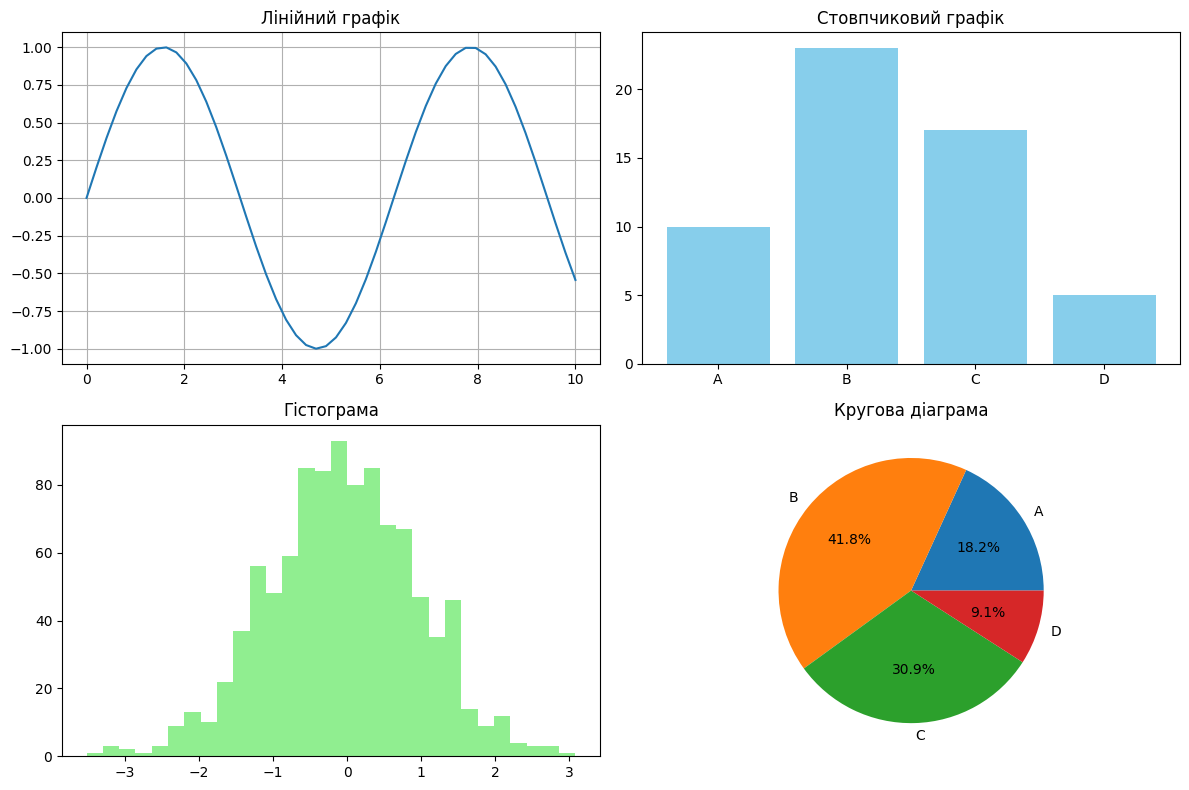

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Дані
x = np.linspace(0, 10, 50)
y = np.sin(x)
categories = ['A', 'B', 'C', 'D']
values = [10, 23, 17, 5]

plt.figure(figsize=(12, 8))

# Лінійний графік
plt.subplot(2, 2, 1)
plt.plot(x, y, label='sin(x)')
plt.title('Лінійний графік')
plt.grid(True)

# Стовпчиковий графік
plt.subplot(2, 2, 2)
plt.bar(categories, values, color='skyblue')
plt.title('Стовпчиковий графік')

# Гістограма
plt.subplot(2, 2, 3)
data = np.random.randn(1000)
plt.hist(data, bins=30, color='lightgreen')
plt.title('Гістограма')

# Кругова діаграма
plt.subplot(2, 2, 4)
plt.pie(values, labels=categories, autopct='%1.1f%%')
plt.title('Кругова діаграма')

plt.tight_layout()
plt.savefig('my_dashboard.png', dpi=300)

#### Кореляційна матриця в Matplotlib

Без підписів зі значеннями кореляцій.

In [ ]:
# Прикладні дані: випадкова матриця кореляцій
np.random.seed(0)
data = np.random.rand(5, 5)

In [ ]:
data.shape

(5, 5)

In [ ]:
type(data)

numpy.ndarray

In [ ]:
corr = np.corrcoef(data)

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
corr

array([[ 1.        ,  0.07728112,  0.38783087, -0.61705212,  0.57560937],
       [ 0.07728112,  1.        ,  0.73848658,  0.38617619,  0.29781032],
       [ 0.38783087,  0.73848658,  1.        , -0.28594208,  0.85471571],
       [-0.61705212,  0.38617619, -0.28594208,  1.        , -0.73990471],
       [ 0.57560937,  0.29781032,  0.85471571, -0.73990471,  1.        ]])

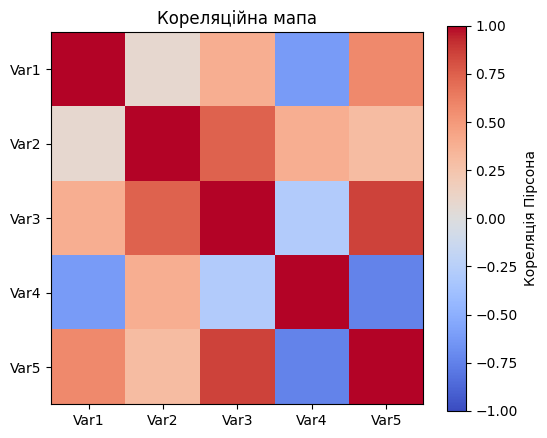

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Кореляція Пірсона')
plt.title('Кореляційна мапа')

# Підписи осей
plt.xticks(range(5), [f'Var{i+1}' for i in range(5)])
plt.yticks(range(5), [f'Var{i+1}' for i in range(5)])

plt.show()

З зазначенням значень кореляцій буде дещо складніше. Далі в лекції дізнаємось, як подібний графік будувати за 2 рядки коду.

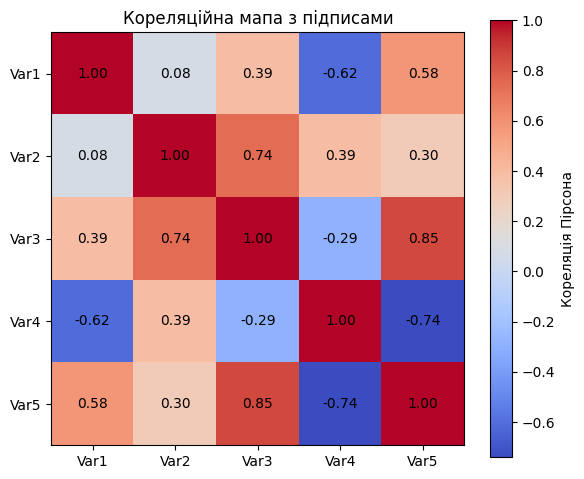

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# Відображаємо матрицю як картинку
cax = ax.imshow(corr, cmap='coolwarm')

# Додаємо кольорову шкалу
fig.colorbar(cax, ax=ax, label='Кореляція Пірсона')

# Підписи осей
labels = [f'Var{i+1}' for i in range(5)]
ax.set_xticks(range(5))
ax.set_xticklabels(labels)
ax.set_yticks(range(5))
ax.set_yticklabels(labels)

# Додаємо підписи значень усередині клітинок
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        text = ax.text(j, i, f"{corr[i, j]:.2f}",
                       ha="center", va="center", color="black")

ax.set_title('Кореляційна мапа з підписами')
plt.tight_layout()
plt.show()


У Pandas немає вбудованого типу графіка для heatmap або матриць кореляцій. Але ви можете зробит градієнтне забарвлення таблиці або порахувати кореляції і відобразити з matplotlib чи seaborn.
Нагадаємо як робити градієнтне забарвлення таблиці.

In [ ]:
corr

array([[ 1.        ,  0.07728112,  0.38783087, -0.61705212,  0.57560937],
       [ 0.07728112,  1.        ,  0.73848658,  0.38617619,  0.29781032],
       [ 0.38783087,  0.73848658,  1.        , -0.28594208,  0.85471571],
       [-0.61705212,  0.38617619, -0.28594208,  1.        , -0.73990471],
       [ 0.57560937,  0.29781032,  0.85471571, -0.73990471,  1.        ]])

In [ ]:
pd.DataFrame(corr, columns=labels, index=labels).round(2).style.background_gradient(cmap='coolwarm')

,Var1,Var2,Var3,Var4,Var5
Var1,1.000000,0.080000,0.390000,-0.620000,0.580000
Var2,0.080000,1.000000,0.740000,0.390000,0.300000
Var3,0.390000,0.740000,1.000000,-0.290000,0.850000
Var4,-0.620000,0.390000,-0.290000,1.000000,-0.740000
Var5,0.580000,0.300000,0.850000,-0.740000,1.000000


### Які тонкі налаштування доступні в maplotlib

Matplotlib дає можливість налаштувати:

1. **Різні стилі ліній** - кожна метрика має свій стиль (суцільна, пунктирна, крапками)
2. **Заливка між лініями** - візуалізує діапазон значень
3. **Анотації** - виділяємо важливі точки з поясненнями
4. **Кастомна сітка** - major та minor gridlines
5. **Додаткові лінії** - середнє за рік
6. **Виділені зони** - позначаємо важливі періоди
7. **Текстові блоки** - додаткова статистика прямо на графіку
8. **Покращена легенда** - з тінню та прозорістю
9. **Форматування дат** - показуємо тільки назви місяців
10. **Налаштування рамки** - товщі границі

Це неможливо зробити через простий `df.plot()` - потрібен прямий доступ до matplotlib API для такого рівня кастомізації.

При цьому часто ми можемо створити базовий графік або з Pandas, або з Matplotlib. І далі дописувати форматування.

**Розглянемо приклад складного форматування.**


In [ ]:
import matplotlib.dates as mdates

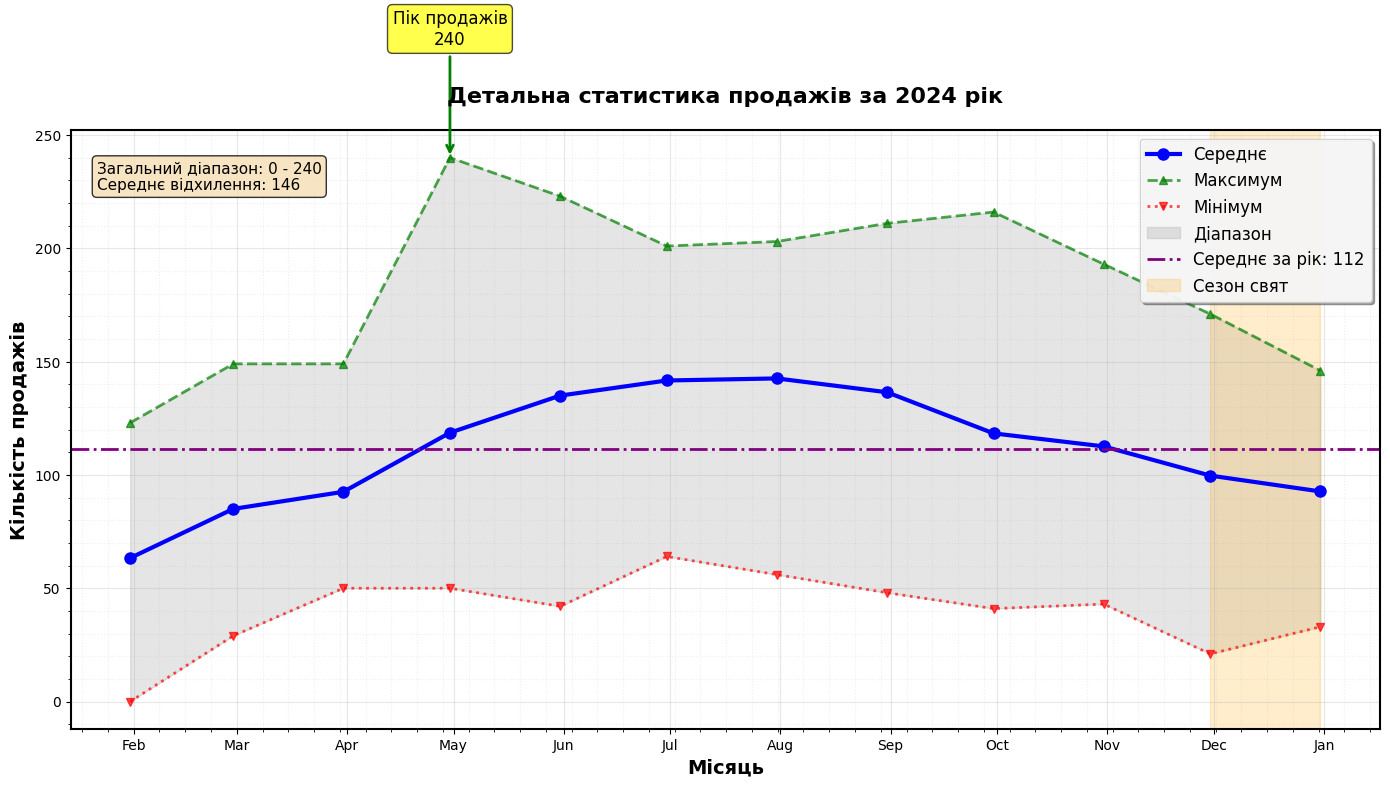

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# Малюємо лінії з різними стилями
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для екстремальних значень
max_idx = monthly_stats['max'].idxmax()
max_val = monthly_stats['max'].max()
ax.annotate(f'Пік продажів\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість продажів', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика продажів за 2024 рік',
             fontsize=16, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = sales_data['sales'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Виділяємо зони (листопад-грудень)
if len(monthly_stats) >= 12:
    ax.axvspan(monthly_stats.index[10], monthly_stats.index[11], alpha=0.2,
               color='orange', label='Сезон свят')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальний діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Середнє відхилення: {(monthly_stats["max"] - monthly_stats["min"]).mean():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


Подібним чином, ми могли б побудувати базовий графік і з Pandas, задавши різні стилі ліній. Але далі налаштування все одно йдуть з maplotlib.

**Чому базовий графік може бути побудований з Pandas?**

Тому що:
* `df.plot()` — це лише **зручний виклик поверх matplotlib**, який повертає `matplotlib.axes.Axes` об’єкт.
* Після цього можна працювати з `plt` або отриманим `ax`, як завжди в `matplotlib`.

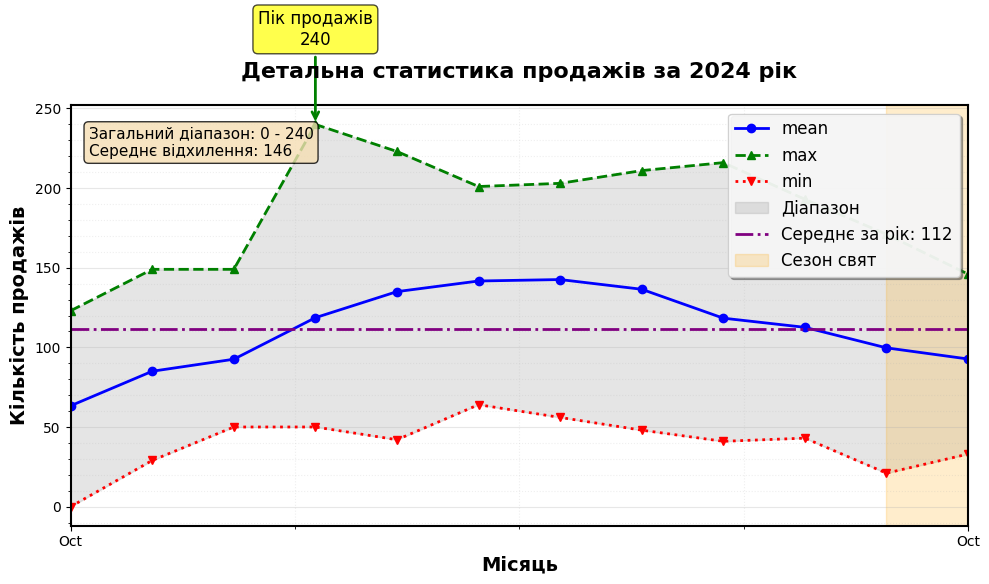

In [ ]:
ax = monthly_stats.plot(style=['bo-', 'g^--', 'rv:'], linewidth=2, figsize=(10, 6))

# НИЖЧЕ КОД ПОПЕРЕДНІЙ БЕЗ ЗМІН
# Заливка між max та min (правильний синтаксис)
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для екстремальних значень
max_idx = monthly_stats['max'].idxmax()
max_val = monthly_stats['max'].max()
ax.annotate(f'Пік продажів\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість продажів', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика продажів за 2024 рік', fontsize=16, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = sales_data['sales'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Виділяємо зони (листопад-грудень)
if len(monthly_stats) >= 12:
    ax.axvspan(monthly_stats.index[10], monthly_stats.index[11], alpha=0.2,
               color='orange', label='Сезон свят')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальний діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Середнє відхилення: {(monthly_stats["max"] - monthly_stats["min"]).mean():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

Як бачимо - все вийшло крім форматування дат. Таке буває. Можна пошукати інший варіант задачі базового графіку, або все ж задати його з matplotlib, або відмовитись від нестандартного форматування осей.

Загалом, якщо вам треба якийсь гарний графік, де треба matplotlib - найшвидше - згенерувати форматування з ChatGPT. І якщо щось не виходить - виправляти на основі власного розуміння, як все працює і з переглядом документації.

## 6. Seaborn - гарні статистичні візуалізації

**Seaborn** — бібліотека для створення статистичних графіків. Побудована на основі Matplotlib, тісно інтегрована з pandas. Має зручніший інтерфейс у деяких випадках (швидше будувати складні графіки) та приємніший стандартний стиль.

**Використовуйте Seaborn коли:**
- Працюєте зі статистичними даними
- Потрібні красиві графіки "з коробки"
- Візуалізуєте багатовимірні дані
- Потрібні складні статистичні графіки

Із `seaborn` можна в тому числі побудувати всі ті самі базові графіки, як і з Pandas/matplotlib (line, bar, box, histogram).

- Галерея seaborn для натхнення: https://seaborn.pydata.org/
- Документація seaborn для розуміння, які графіки є: https://seaborn.pydata.org/tutorial/introduction.html
Але я покажу, які є особливі графіки, які часто використовуються на практиці.

Імпортується `seaborn` наступним чином.


In [ ]:
import seaborn as sns

In [ ]:
# Встановлюємо стиль
sns.set_theme(style="whitegrid")

In [ ]:
# Додамо колонки для аналізу
sales_data['month'] = sales_data.index.month_name()
sales_data['weekday'] = sales_data.index.day_name()

In [ ]:
monthly_stats['mean']

,mean
2024-01-31,63.322581
2024-02-29,85.000000
2024-03-31,92.548387
2024-04-30,118.633333
2024-05-31,135.000000
2024-06-30,141.666667
2024-07-31,142.580645
2024-08-31,136.483871
2024-09-30,118.333333
2024-10-31,112.580645


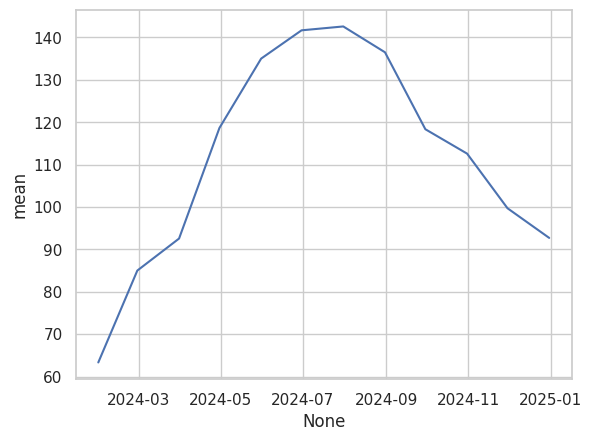

In [ ]:
sns.lineplot(monthly_stats, x=monthly_stats.index, y='mean');

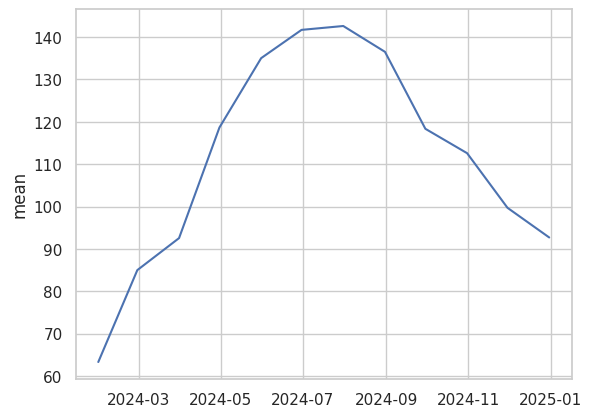

In [ ]:
sns.lineplot(monthly_stats['mean']);

In [ ]:
sales_data

,visitors,sales,conversion,avg_order_value,income,weekday,month
2024-01-01,2167,75,0.032994,89.753640,6731.523007,Monday,January
2024-01-02,1983,52,0.036120,91.450902,4755.446886,Tuesday,January
2024-01-03,2226,86,0.035063,70.794979,6088.368237,Wednesday,January
2024-01-04,2495,54,0.035488,100.061359,5403.313391,Thursday,January
2024-01-05,1976,82,0.031135,94.492687,7748.400304,Friday,January
...,...,...,...,...,...,...,...
2024-12-26,3241,109,0.034080,72.565835,7909.676037,Thursday,December
2024-12-27,3550,123,0.035092,97.766750,12025.310241,Friday,December
2024-12-28,2563,83,0.026738,94.113609,7811.429547,Saturday,December
2024-12-29,2722,61,0.022301,103.277044,6299.899700,Sunday,December


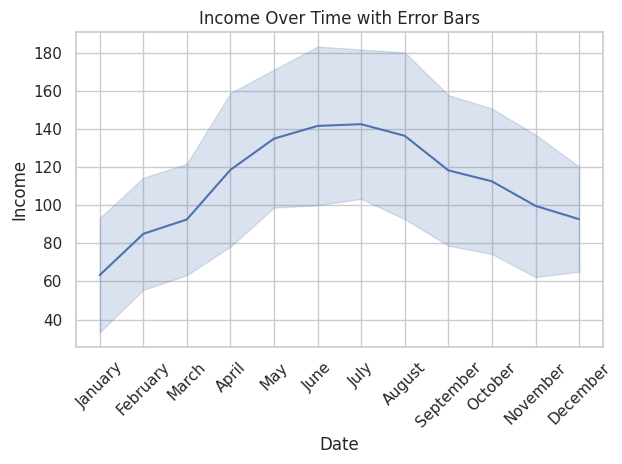

In [ ]:
sns.lineplot(sales_data, x='month', y='sales', errorbar='sd')
plt.title('Income Over Time with Error Bars')
plt.xlabel('Date')
plt.ylabel('Income')
plt.xticks(rotation=45)
plt.tight_layout();

### Heatmap кореляцій між числовими ознаками

In [ ]:
correlation = sales_data[['sales', 'visitors', 'conversion', 'income']].corr()

In [ ]:
correlation

,sales,visitors,conversion,income
sales,1.000000,0.711627,0.614408,0.939353
visitors,0.711627,1.000000,0.121789,0.805119
conversion,0.614408,0.121789,1.000000,0.482185
income,0.939353,0.805119,0.482185,1.000000


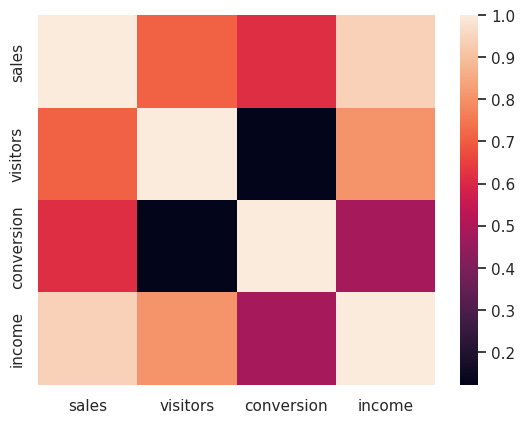

In [ ]:
sns.heatmap(correlation);

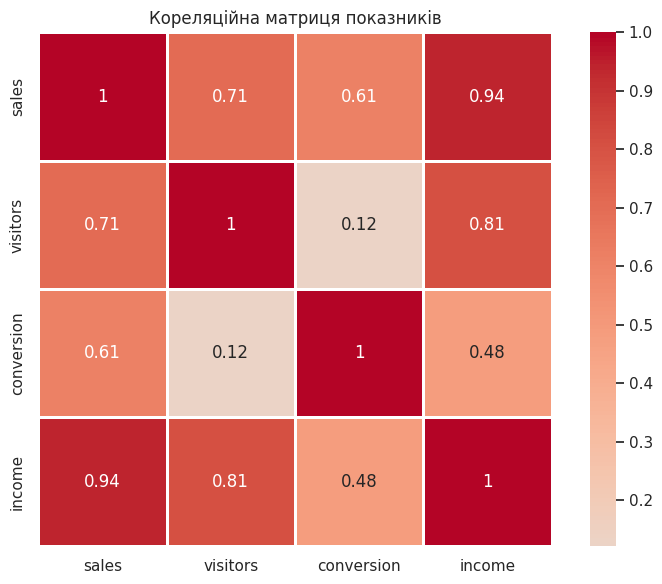

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

### Violin plot для розподілів в категоріях

Гарний нестандартний графік. Мікс гістограми і boxplot. Пасує, коли хочемо подивитись детальний розподіл даних по категоріям.

Додаткова зручність, що тут одразу можемо задати порядок відображення категорій в налаштуваннях функції візуалізації.

Також зверніть увагу, що всі додаткові налаштування ми знову робимо з `maplotlib` - бо це наша базова бібліотека, до якої зводиться функціонал і візуалізацій у Pandas, і візуалізацій у Seaborn.

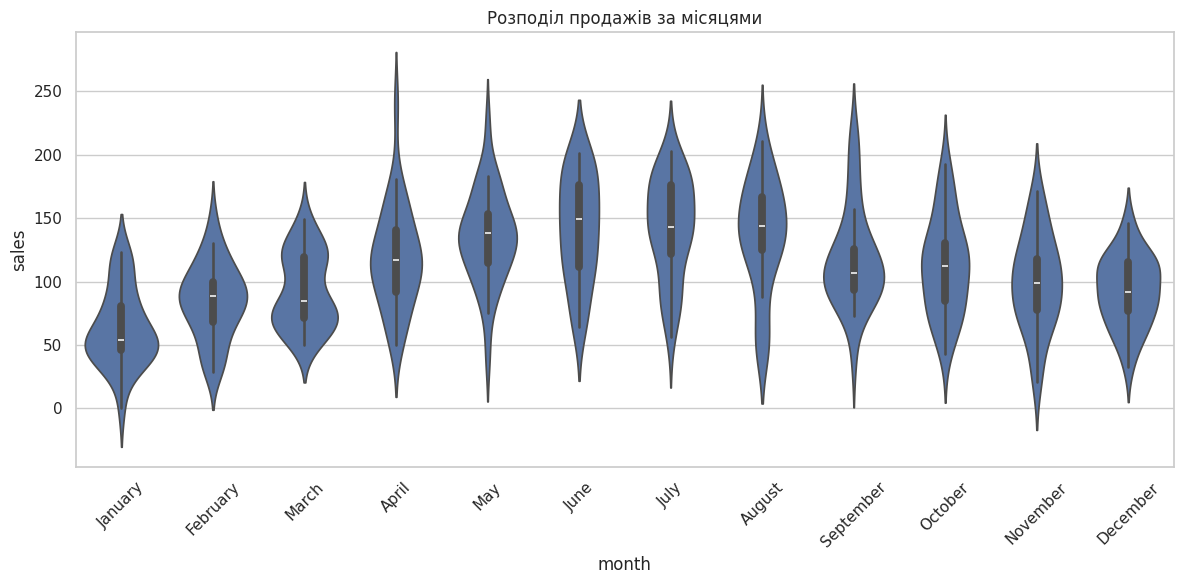

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=sales_data, x='month', y='sales',
              #  order=['January', 'February', 'March', 'April', 'May', 'June',
              #         'July', 'August', 'September', 'October', 'November', 'December']
               )
plt.xticks(rotation=45)
plt.title('Розподіл продажів за місяцями')
plt.tight_layout()
plt.show()

### Графіки для мультиваріативного аналізу

Pairplot - певно, найпопулярніший графік в seaborn.


In [ ]:
sales_data.shape

(365, 7)

In [ ]:
sales_data.sample(frac=0.1).shape

(36, 7)

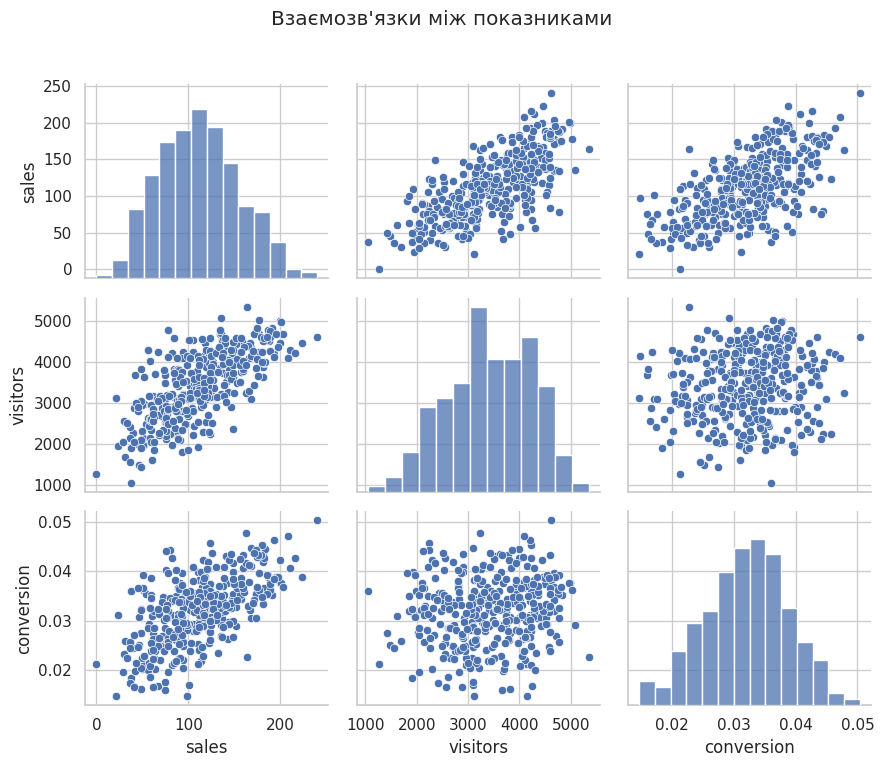

In [ ]:
sample_df = sales_data[['sales', 'visitors', 'conversion']]
# .sample(100) # корисно встановити, якщо у нас багато даних (кілька тисяч рядків і багато колонок), інакше буде довго будуватись графік
sns.pairplot(sample_df, height=2.5, aspect=1.2)
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

В pairplot можна замінювати типи графіків на
- верхній половині
- нижній половині
- по діагоналі.

Часто pairplot зображують так, що половина кореляційної матриці містить кореляційні коефіцієнти, а половина - графіки розсіювання.

**Можна також додавати розбивку по категоріям та накласти візуалізації категорій різними кольорами на одні і ті сами графіки. Це дасть можливість провести ще глибший аналіз та порівняти статистику між категоріями.**

Завантажимо набір даних `penguins` для демонстрації.

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


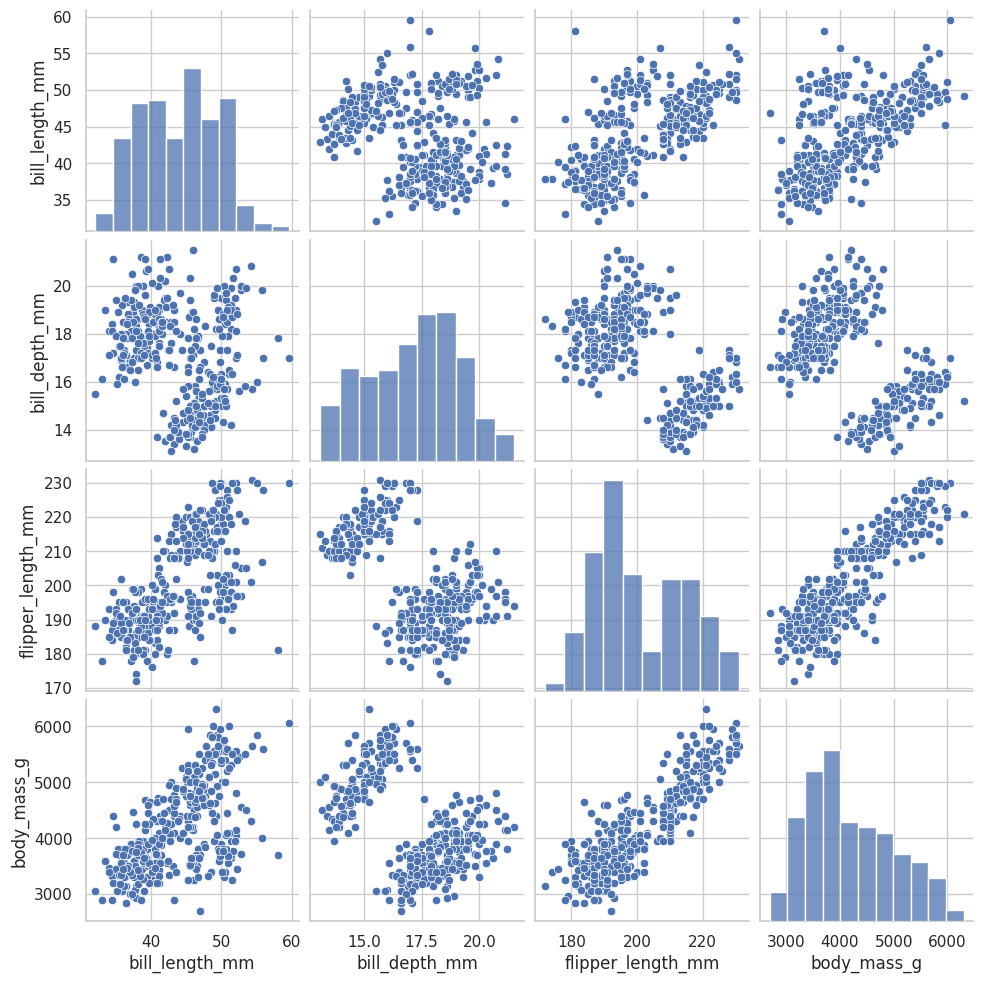

In [ ]:
sns.pairplot(penguins);

Розібʼємо відображення за категоріями:

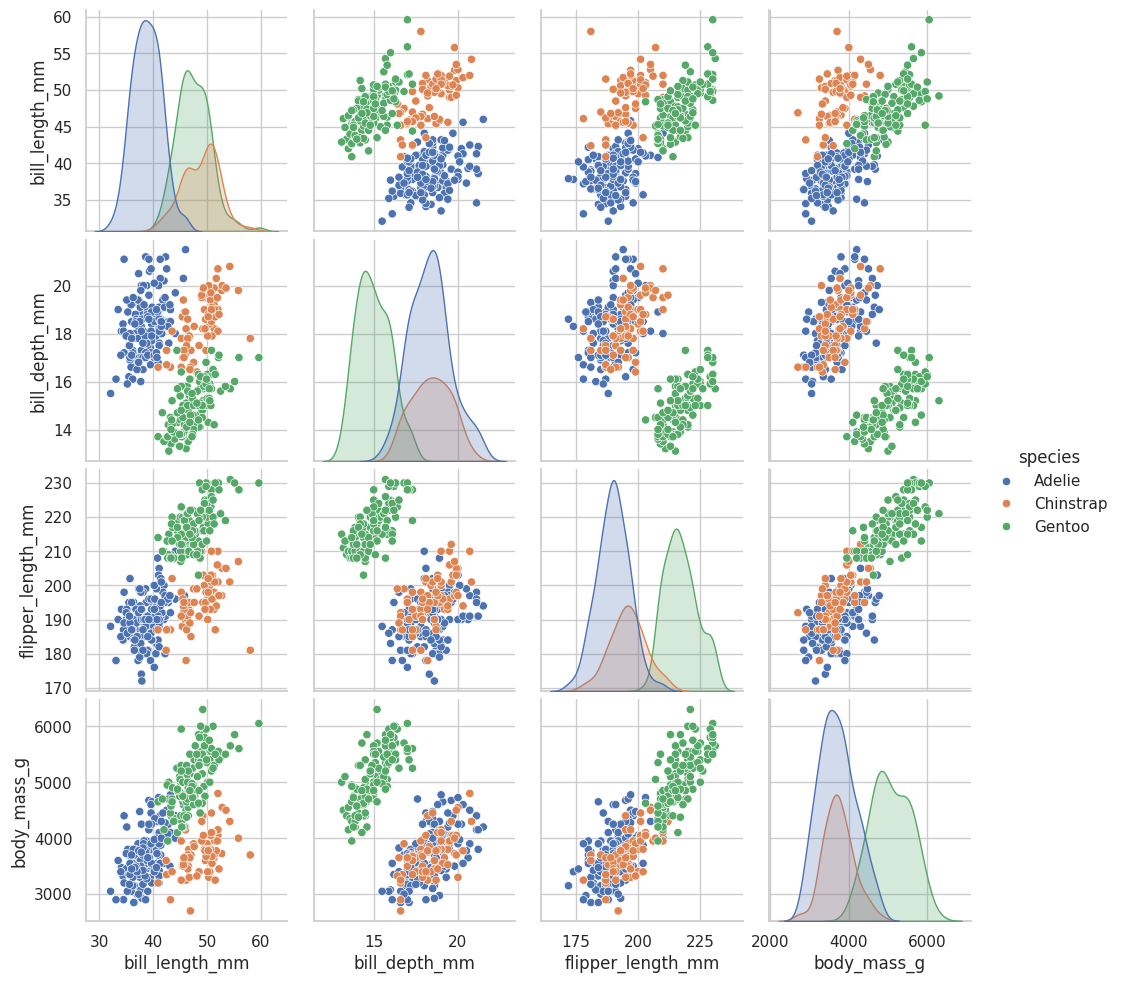

In [ ]:
sns.pairplot(penguins, hue="species");

Часто ці pairplots будують з зазначенням кореляції в одній половині, і графіків - в іншій. Якщо ми хочемо зробити візуалізацію з коефіцієнтом кореляції:

In [ ]:
# Маємо спершу видалити відсутні значення, або якось їх заповнити
non_na_penguins = penguins.dropna();

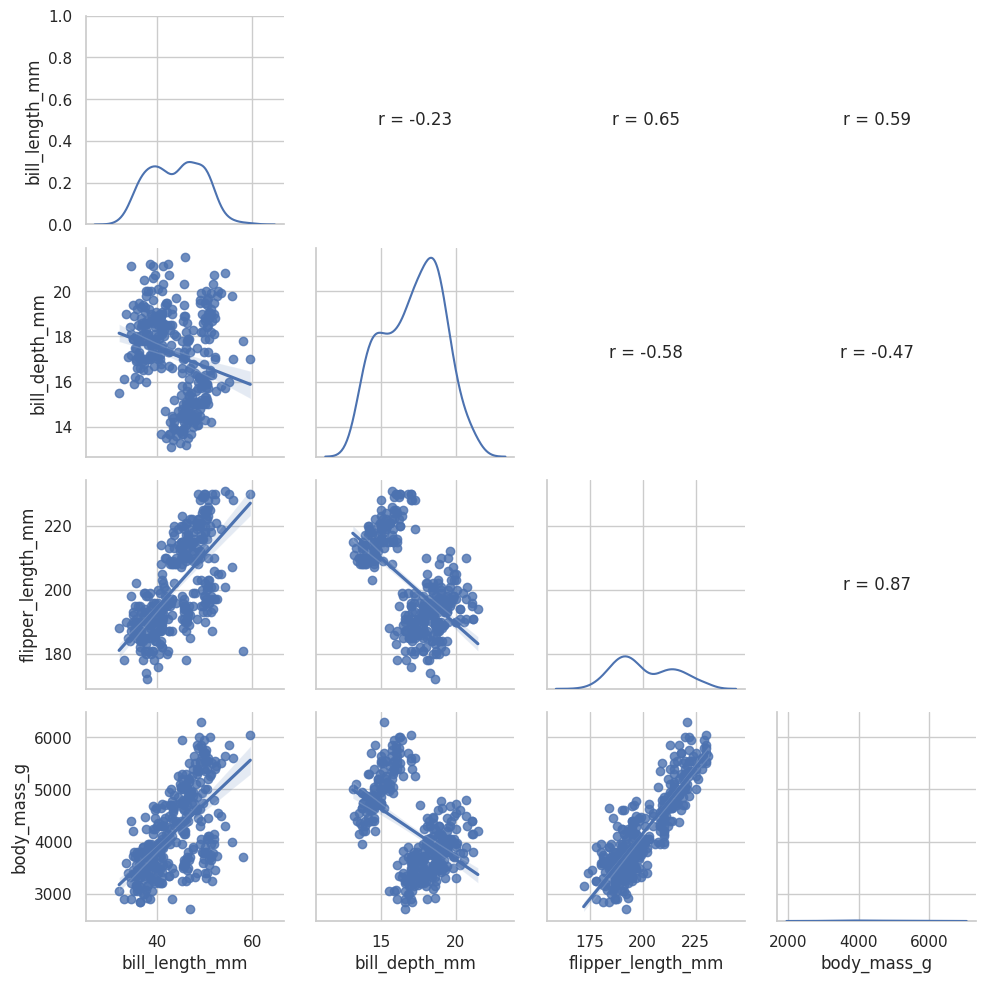

In [ ]:
import numpy as np

# Функція для відображення коефіцієнта кореляції в комірках
def corrfunc(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}", xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=12)
    ax.set_axis_off()

# Створюємо PairGrid — шаблон для комбінованого графіка
g = sns.PairGrid(non_na_penguins)

# Нижній трикутник — regplot - графік розсіювання, але з лінією тренду (регресії)
g.map_lower(sns.regplot)

# Діагональ — kernel density estimate графіки - "згладжені" гістограми
g.map_diag(sns.kdeplot)

# Верхній трикутник — коефіцієнти кореляції Пірсона
g.map_upper(corrfunc);


Ще один приклад цікавої діаграми - `jointplot` - це графік розсіювання з розподілами даних.

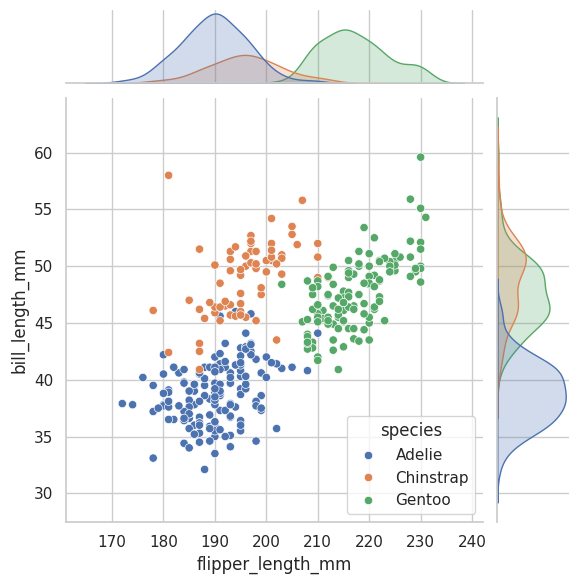

In [ ]:
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species");

## 7. Інтерактивні візуалізації з Plotly

**Plotly** — бібліотека для створення інтерактивних графіків. Вона підходить для побудови дашбордів і дає можливості приближення/віддалення, навігації та гнучкої інтерактивної аналітики.


### 🔹 Коли використовувати Plotly:

* Потрібна інтерактивність (**zoom**, **hover**, **click**)
* Створюєте інтерактивні **дашборди**
* Публікуєте графіки у вебі
* Працюєте з великими даними (зручно фільтрувати, групувати)


### 🔹 Як працювати з Plotly: **Express vs Graph Objects**

* **`plotly.express` (`px`)** — модуль для **швидкої побудови** інтерактивних графіків.
  Підходить, коли потрібен **один простий графік**: 1-2 рядки коду, автоматичні підписи (`hover_data`), кольори й стилі.
  ✔ Зручно для швидкого EDA, ноутбуків, презентацій.

* **`plotly.graph_objects` (`go`)** — низькорівневий модуль.
  Дає **повний контроль**: ви створюєте графіки поелементно (`Scatter`, `Bar`, `Histogram`), налаштовуєте `hovertemplate`, кольори, анімації, комбінуєте кілька графіків у **дашборд** через `make_subplots`.
  ✔ Потрібен, якщо:

  * Багато графіків в одному полотні.
  * Складний дашборд.
  * Багато кастомних підписів, легенд і стилів.


📌 **Порада:**

> Для **швидкого прототипу** — почніть з `px`.
> Для **серйозного дашборду** — комбінуйте `px` і `go` або переходьте повністю на `go`.



In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
viz_data = sales_data.reset_index()
viz_data.rename(columns={'index': 'date'}, inplace=True)

### Базовий інтерактивний лінійний графік

In [ ]:
px.line(viz_data, x='date', y='sales',
              title='Інтерактивний графік продажів')

In [ ]:
fig = px.line(viz_data, x='date', y='sales',
              title='Інтерактивний графік продажів')
fig.update_traces(line_width=2)
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    height=500
)

### Інтерактивний scatter з додатковою інформацією

In [ ]:
px.scatter(viz_data,
                 x='visitors',
                 y='sales'
)

In [ ]:
fig = px.scatter(viz_data,
                 x='visitors',
                 y='sales',
                 size='income',
                 color='conversion',
                 hover_data=['date', 'month'],
                 title='Аналіз ефективності продажів',
                 labels={'conversion': 'Конверсія (%)'})
fig.update_layout(height=600)
fig.show()


Якщо треба округлити чи якось змінити формат даних - маємо то зробити в самому датафреймі. Наприклад, `viz_data.round(2)`.

### Дашборд з кількома графіками

Коли ми будуємо **складний дашборд** з кількома графіками - то використовуємо тут **`make_subplots`**, і тоді часто зручніше працювати вже з модулем **`plotly.graph_objects` (`go`)**.


### 📌 Чому?

* **`make_subplots`** збирає кілька різних типів графіків в одну фігуру.
* `px` окремо не вміє будувати багато підсюжетів одразу — ми беремо `.data[0]` з `px` або пишемо `go.Scatter`, `go.Bar`, `go.Histogram` тощо.
* Для кожного `Trace` (так називаються тут підграфіки) треба **окремо визначати**, як виглядатиме hover - дані, які виводяться при наведенні.

## 🗂️ Як задавати hover у `go`?

В `go` **немає `hover_data` як у `px`**.
Тут працюють два механізми:
1️⃣ `customdata` — передаємо додаткові стовпці для ховера
2️⃣ `hovertemplate` — повністю прописуємо текст підказки вручну.



## ✅ Мінімальний приклад `plotly.graph_objects`

### 📌 Як будується графік у `go`

**Головне правило:**

> У `go` ми завжди самі:
> 1️⃣ Створюємо фігуру →
> 2️⃣ Додаємо у неї трейс →
> 3️⃣ Відображаємо `.show()`



### 🔹 Простий приклад: точкова діаграма


In [ ]:
import plotly.graph_objects as go

# 1️⃣ Готуємо дані
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 17, 12]

# 2️⃣ Створюємо фігуру
fig = go.Figure()

# 3️⃣ Додаємо трейс (go.Scatter)
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers+lines',  # точки + лінії
        marker=dict(
            size=10,
            color='royalblue'
        ), # це наша hover_data
        hovertemplate='X: %{x}<br>Y: %{y}<br>', # формат відображення
        name='Продажі'
    )
)

# 4️⃣ Додаємо оформлення
fig.update_layout(
    title='Простий приклад Scatter з go',
    xaxis_title='X',
    yaxis_title='Y',
    template='plotly_white'
)

# 5️⃣ Показуємо
fig.show()

In [ ]:
px.line(x=x,y=y)

## 🔑 Як це працює

✅ **`go.Figure()`** — створює пусте полотно.

✅ **`go.Scatter(...)`** — створює один шар (trace).
Може бути `Scatter`, `Bar`, `Histogram` тощо.

✅ **`add_trace`** — додає цей шар у фігуру.

✅ **`update_layout`** — задає заголовки, осі, тему.

✅ **`fig.show()`** — запускає рендер у Jupyter або браузері.



## 📌 Головне про `go`

* `go` = **повний ручний контроль**.
* Кожен елемент додаєте самі.
* Добре для дашбордів, `subplots` і складної структури.
* Немає «магії» як у `px`: усе явно.



Враховуючи це і попередній приклад, давайте створимо дашборд з кількома графіками.

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Динаміка продажів', 'Розподіл конверсії',
                    'Топ-10 днів', 'Продажі vs Відвідувачі')
)

# Графік 1: Лінійний
fig.add_trace(
    go.Scatter(
        x=sales_data.index,
        y=sales_data['sales'],
        mode='lines',
        name='sales',
        hovertemplate='Дата: %{x}<br>Продажі: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# Графік 2: Гістограма
fig.add_trace(
    go.Histogram(
        x=sales_data['conversion'],
        name='conversion',
        nbinsx=30,
        hovertemplate='Конверсія: %{x}<br>Кількість: %{y}<extra></extra>'
    ),
    row=1, col=2
)

# Графік 3: Барплот
top_days = sales_data.nlargest(10, 'income')
fig.add_trace(
    go.Bar(
        x=top_days.index.strftime('%Y-%m-%d'),
        y=top_days['income'],
        name='income',
        hovertemplate='Дата: %{x}<br>Дохід: %{y}<extra></extra>'
    ),
    row=2, col=1
)

# Графік 4: Scatter з кольором
fig.add_trace(
    go.Scatter(
        x=sales_data['visitors'],
        y=sales_data['sales'],
        mode='markers',
        marker=dict(
            color=sales_data['conversion'],
            colorscale='viridis',
            colorbar=dict(title='Конверсія')
        ),
        hovertemplate=(
            'Відвідувачі: %{x}<br>'
            'Продажі: %{y}<br>'
            'Конверсія: %{marker.color:.5f}<extra></extra>'
        )
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text="Комплексний дашборд продажів"
)

fig.show()

### 3D візуалізація

In [ ]:
fig = px.scatter_3d(sales_data.sample(100).reset_index(),
                    x='visitors', y='sales', z='income',
                    color='conversion', size='sales',
                    title='3D аналіз продажів')
fig.update_layout(height=700)
fig.show()


### Експорт інтерактивних графіків у файл


Ми можемо експортувати наші графіки з plolty у формат html та png/jpeg/svg.

In [ ]:
# Зберегти як HTML
fig.write_html("dashboard.html")

Для збереження в png треба встановити додаткову бібліотеку (часто після цього треба перезавантажити сесію).

In [ ]:
pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.5 MB/s eta 0:00:00


А також при роботі в Google Colab треба встановити Chrome for Plotly.

In [ ]:
!plotly_get_chrome -y

Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.11/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [ ]:
# Зберегти як статичне зображення
fig.write_image("graph.png")

# Експорт для вставки в презентації
fig.write_image("graph.svg")


## 7. Практичні поради та best practices

### Вибір правильного типу візуалізації

| Тип даних | Рекомендована візуалізація | Бібліотека |
|-----------|---------------------------|------------|
| Часові ряди | Line plot, Area plot | Pandas/Plotly |
| Порівняння категорій | Bar plot, Horizontal bar | Pandas |
| Розподіл | Histogram, Box plot, Violin | Seaborn |
| Кореляції | Scatter, Heatmap | Seaborn/Plotly |
| Частини від цілого | Pie (обережно!), Stacked bar | Pandas |
| Географічні дані | Choropleth map | Plotly |

### Загальні рекомендації

1. **Простота понад усе**: Не перевантажуйте графіки
2. **Правильні кольори**: Використовуйте colorblind-friendly палітри
3. **Підписи та легенди**: Завжди підписуйте осі та додавайте легенду
4. **Контекст**: Додавайте середні значення, тренди
5. **Інтерактивність використовуємо з розумом**: Не всі графіки потребують інтерактивності



## Підсумок

- **Pandas** - швидкий старт, базові графіки
- **Matplotlib** - повний контроль, складні композиції
- **Seaborn** - статистичні візуалізації, естетика
- **Plotly** - інтерактивність, веб, дашборди

Пам'ятайте: найкращий графік - це той, який чітко передає вашу історію даних!

## Корисні ресурси

- [Pandas Visualization](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [Seaborn Gallery](https://seaborn.pydata.org/examples/index.html)
- [Plotly Python](https://plotly.com/python/)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Data-to-Viz](https://www.data-to-viz.com/) - вибір правильної візуалізації
- [ColorBrewer](https://colorbrewer2.org/) - підбір кольорів